# Exercise 5B: Steady-State Groundwater Model - Calibration

Elco Luijendijk, March 2026
<elco.luijendijk@uib.no>


## Exercise Sequence (5A → 5B → 5C)

- **Exercise 5A** (`exercise_5a_model_data.ipynb`): prepare model input datasets (elevation, recharge, geology, surface water).
- **Exercise 5B** (this notebook): build and calibrate the steady-state groundwater model.

## Introduction

In this exercise you build and calibrate a steady-state depth-integrated (one-layer) groundwater model for a real Norwegian catchment. “Depth-integrated” means that we represent all groundwater flow in a single map-view layer. This is a justified simplification for basin-scale models that focus on the watertable and the exchange between groundwater and surface water bodies.

You will use the geospatial datasets prepared in Exercise 5a, which include elevation , recharge, surface water locations, and geology and apply calibration methods similar to Exercises 2 and 3, but extended to two spatial dimensions.


## Objectives

- Set up a depth-integrated groundwater model from geospatial input datasets.
- Calibrate against multiple data types: observed water-table depths, seepage behaviour, and surface-water connectivity.
- Evaluate model quality with different metrics, RMSE, R², and a surface-water check for losing reaches (places where the modelled water table is below the river or lake bed, physically unrealistic for gaining streams).
- Explore the effect of uniform and spatially variable transmissivity on modelled watertable depths.

## What to hand in

Hand in a short report documenting your model: describe the catchment, explain your calibration choices, show key maps (model setup, calibration quality, spatial water-table distribution), and briefly interpret the water budget. Include your completed notebook as an appendix.

## Workflow

1. Load and visually inspect model input data.
2. Run a single-parameter uniform transmisssivity baseline model, and vary the transmissivity to explore what the effect is and to find the best-fitting model. Optionally calibrate transmissivity automatically.
3. Assign different transmissivities for one or more geologic unit. Optionally automatically calibrate transmissivity for one or more units.
4. Compare the modeled watertable depths and the discharge to surface water bodies to observed values.
5. Save the best calibrated transmissivity field for use in Exercise 5C.

*Good luck, and ask for help if you get stuck.*

## Optional: Install missing packages

When running on Google Colab: Run the cell below once to install required packages, then comment it out again. On Google Colab all lines are needed.  If you are running the model locally on your own machine, see the readme for instructions on how to install packages

In [33]:
# uncomment the line below to install required packages, then comment it out again.
#!pip install flopy rasterio xarray cmcrameri affine pysheds

## Imports

In [34]:
from pathlib import Path
import importlib
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize_scalar, minimize
import xarray as xr
import cmcrameri.cm as cmc

# -- Detect runtime environment -------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# -- Download helper scripts when running on Google Colab ----------------------
if IN_COLAB:
    _raw = ('https://raw.githubusercontent.com/'
            'ElcoLuijendijk/GEOV212_hydrogeology_exercises/main/')
    for _s in ['exercise_5_gw_model_utils.py', 'exercise_5_gw_plot_utils.py']:
        urllib.request.urlretrieve(_raw + _s, _s)
    print('Helper scripts downloaded.')

import exercise_5_gw_model_utils as gwu
import exercise_5_gw_plot_utils as gwp

gwu = importlib.reload(gwu)
gwp = importlib.reload(gwp)

# Keep warning output useful for teaching: suppress only known noisy cases.
warnings.filterwarnings(
    'once',
    message='Using fallback solver because FLOPY/MF6 was unavailable*',
)
warnings.filterwarnings(
    'once',
    message='Could not download mf6 executable*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*datetime.*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*tight_layout.*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*constrained_layout.*',
)

if IN_COLAB:
    # jupyter_client calls datetime.utcnow() internally on every cell message
    # in Python 3.12+ this fires a DeprecationWarning on every cell execution.
    # Suppress it here since it is not actionable from user code.
    warnings.filterwarnings(
        'ignore',
        category=DeprecationWarning,
        module='jupyter_client',
    )

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

print(f"Running on {'Google Colab' if IN_COLAB else 'local machine'}")

Helper scripts downloaded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Google Colab


## Model Parameters

The section below contains the most important model parameters. Read through them before running the rest of the notebook, understanding each one will help you build and calibrate the model.

The most important paramameter to change here is the `target_cellsize_m` which determines the resolution of the model. Higher values mean a less accurate model, but shorter runtimes, and vice-versa. Try to set this to a value where the model runs in a reasonably short time so that you are able to explore the effects of different model parameters. Optionally you can choose to run your final model runs at a higher resolution once you are done with model calibration.

In [35]:
# File paths (Colab or local machine)
if IN_COLAB:
    # scratch space on the Colab VM
    data_dir  = Path('/content/drive/MyDrive/GEOV212_model_input')
    model_dir = Path('/content/tmp_mf6_ex5')
else:
    data_dir  = Path('data/model_input')
    model_dir = Path('tmp_mf6_ex5')
model_dir.mkdir(exist_ok=True)

# Target model cell size (m)
# coarser cells = faster model runs, but less accurate
# finer cells = more accurate, but longer model runs and more memory and disk space needed
target_cellsize_m = 100.0

# Assumed uniform aquifer thickness; T = K * b (m)
aquifer_thickness_m = 100.0

# Fixed head at open-sea cells (m a.s.l.)
sea_level_m = 0.0

# Drainage parameter for surface water cells (rivers or lakes)
# Streambed/lake-bed hydraulic conductivity (m/s)
default_drain_bed_k_m_s       = 2e-6
# Streambed/lake-bed thickness (m)
default_drain_bed_thickness_m = 1.0

# Seepage cells outside of surface water bodies (rivers/lakes) are represented as drains with head fixed at the land surface elevation.
# the drainage conductance determines how fast the drainage occurs
# drainage conductance scales with local aquifer K following the equation below:
# C = K[r,c] * dx * dy / drain_coupling_depth_m  (Rushton 2003; Beven 1981)
# Effective coupling depth for upland drain cells (m).
# Larger values = more resistive seepage face = less upland drainage.
# Default 10.0 m avoids over-draining with 100 m cells
drain_coupling_depth_m = 10.0

# Slope correction for steep terrain
# Corrects for longer flow paths between cells in plan-view 2D model
apply_slope_correction = True

# Calibration loss weights.
# The combined loss has two terms (see Part C for details):
#   w_rmse       : weight for the RMSE of modelled vs observed watertable depth at wells
#   w_sw_deficit : weight for the RMSE of the hydraulic head deficit below surface water
#                  features (max(0, sw_level - head) per cell; only losing reaches penalised)
# Equal weights (both 1.0) give both targets the same importance.
# Increase w_sw_deficit to push calibration harder toward gaining surface-water reaches.
cal_weights = {
    'w_rmse'      : 1.0,
    'w_sw_deficit': 1.0,
}

print(f'Data directory : {data_dir.resolve()}')
print(f'Model directory: {model_dir.resolve()}')


Data directory : /content/drive/MyDrive/GEOV212_model_input
Model directory: /content/tmp_mf6_ex5


## Helper functions for plotting

In [36]:

# ── Map helper wrappers ────────────────────────────────────────────────────────
# The actual code lives in exercise_5_gw_plot_utils.py.
# These thin wrappers supply the global `grid` dict automatically so that
# existing call sites (e.g. in the input-data figure below) stay unchanged.

def _cbar(im, ax, label='', **kw):
    """Add a colorbar matched to the axes height."""
    return gwp._cbar(im, ax, label, **kw)

def _panel_h():
    """Map panel height (inches) for the current grid aspect ratio."""
    return gwp._panel_h(nrow, ncol)

def add_map_ticks(ax, **kw):
    """Add easting/northing tick labels to a map axes."""
    return gwp.add_map_ticks(ax, grid, **kw)

def add_map_overlays(ax, **kw):
    """Overlay domain boundary and sea mask."""
    return gwp.add_map_overlays(ax, grid, **kw)

print('Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).')


Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).



---
## Part A: Load and Inspect the Model Input Data

The section below loads all the input data needed for the model to run.
`gwu.load_and_coarsen_inputs` reads five GeoTIFF rasters from `data/model_input/`,
coarsens them to the target cell size, and returns a dictionary of arrays.

**Expected output:**
- Grid loads without errors.
- Non-zero counts for active, sea, and surface-water cells.
- Recharge in a plausible range (50–600 mm/yr for a Norwegian catchment).**

In [37]:
# Load and coarsen all raster inputs to the target cell size
grid_data = gwu.load_and_coarsen_inputs(data_dir, target_cellsize_m)

dem       = grid_data['dem']
sw        = grid_data['sw']
sea       = grid_data['sea']
geo       = grid_data['geo']
rch       = grid_data['rch']
active    = grid_data['active']
transform = grid_data['transform']
delr      = grid_data['delr']
delc      = grid_data['delc']
nrow      = grid_data['nrow']
ncol      = grid_data['ncol']
factor    = grid_data['factor']
native_dx = grid_data['native_dx']

# Derived masks
is_sea   = (sea == 1) & active
sw_cells = (sw > 0) & (sw < 3) & active & ~is_sea

# Convert recharge from m/s to mm/yr for display
rch_mm_yr = rch * 365.25 * 24 * 3600 * 1000

print(f'Coarsening factor: {factor}  (native ~{native_dx:.1f} m -> model ~{delr:.1f} m)')
print(f'Grid: {nrow} rows x {ncol} cols')
print(f'Active cells:          {active.sum():,}')
print(f'Sea cells (CHD):       {is_sea.sum():,}')
print(f'SW cells (lake+river): {sw_cells.sum():,}')
rch_active = rch_mm_yr[active]
print(f'Recharge range (active): {rch_active.min():.0f} - {rch_active.max():.0f} mm/yr')
if rch_active.min() == rch_active.max():
    print('  Note: recharge is spatially uniform.')

# Grid info dict passed to all plotting functions
grid = dict(
    dem=dem, active=active, sw_cells=sw_cells, is_sea=is_sea,
    nrow=nrow, ncol=ncol, delr=delr, delc=delc,
    transform=transform, aquifer_thickness_m=aquifer_thickness_m,
    # Extra arrays needed for the water-budget figure inside plot_model_output
    rch=rch, sw_raw=sw, sea_raw=sea,
)


Coarsening factor: 10  (native ~10.0 m -> model ~100.0 m)
Grid: 67 rows x 106 cols
Active cells:          5,898
Sea cells (CHD):       3,419
SW cells (lake+river): 39
Recharge range (active): 377 - 424 mm/yr


## Plot input data overview

Plot all six input arrays (elevation, recharge, geology, surface water, sea mask, active domain) as a single column of maps for a check of the input data.


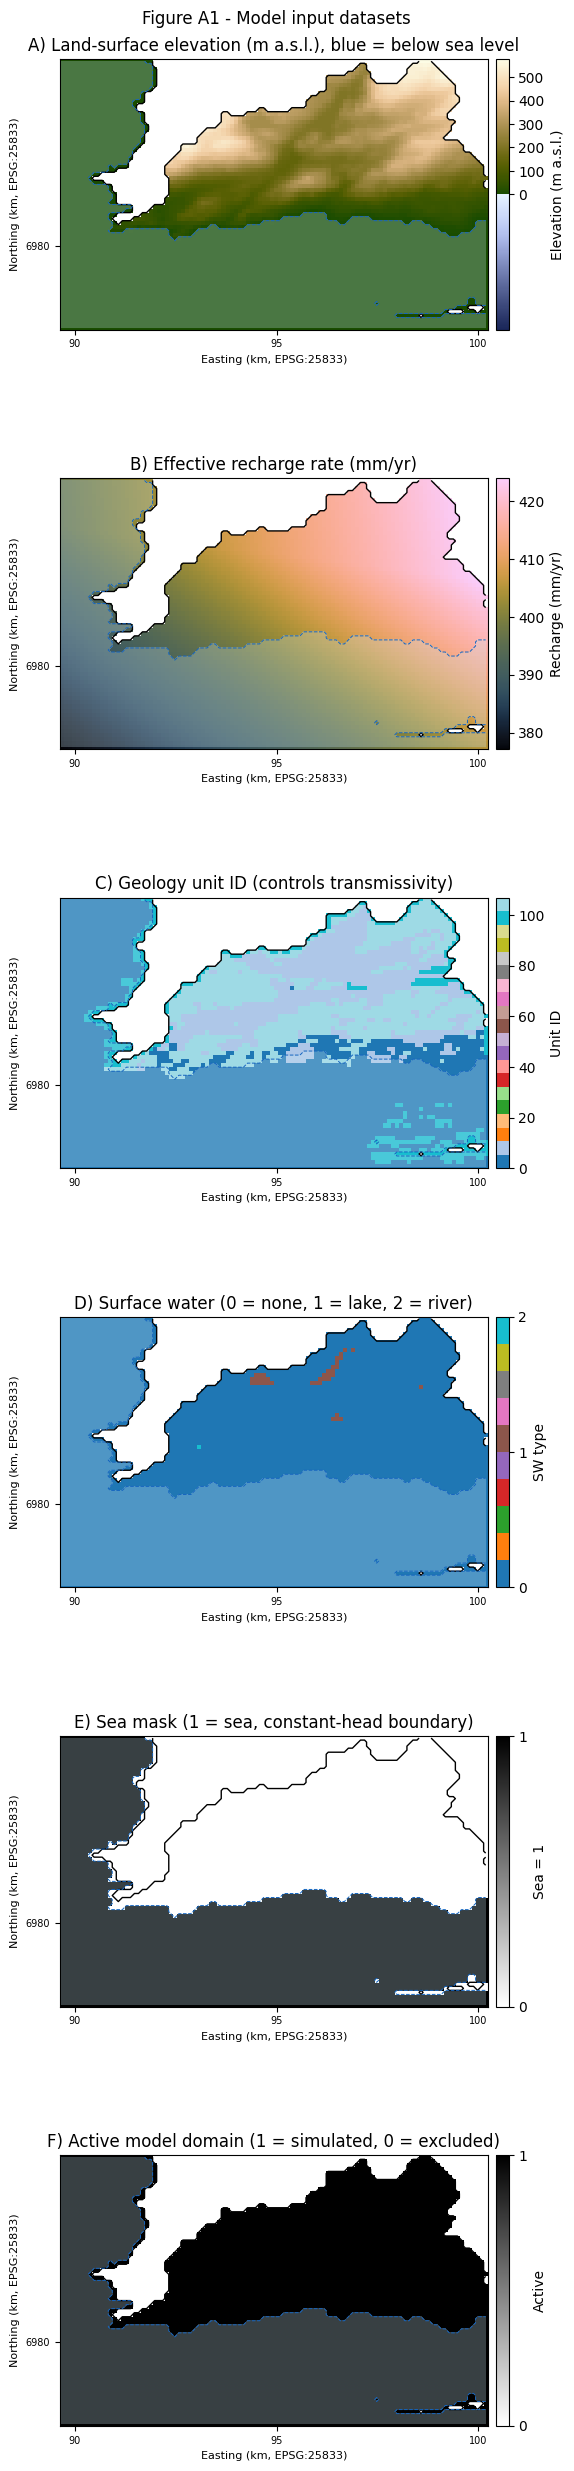

In [38]:
# Figure A1: Input data overview (6 panels)
ph = _panel_h()
fig, axes = plt.subplots(6, 1, figsize=(8, 6 * ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.97, bottom=0.01, hspace=0.55)

# Elevation: anchor colormap at 0 m (cmc.oleron: blue below sea level, land tones above)
from matplotlib.colors import TwoSlopeNorm
_dem_min = float(np.nanmin(dem[active]))
_dem_max = float(np.nanmax(dem[active]))
_elev_norm = TwoSlopeNorm(vmin=min(_dem_min, -5.0), vcenter=0.0, vmax=_dem_max)
im0 = axes[0].imshow(np.where(active, dem, np.nan), cmap=cmc.oleron, norm=_elev_norm)
axes[0].set_title('A) Land-surface elevation (m a.s.l.), blue = below sea level')
_cbar(im0, axes[0], 'Elevation (m a.s.l.)')

im1 = axes[1].imshow(np.where(active, rch_mm_yr, np.nan), cmap=cmc.batlowK)
axes[1].set_title('B) Effective recharge rate (mm/yr)')
_cbar(im1, axes[1], 'Recharge (mm/yr)')

im2 = axes[2].imshow(np.where(active, geo, np.nan), cmap="tab20")
axes[2].set_title('C) Geology unit ID (controls transmissivity)')
_cbar(im2, axes[2], 'Unit ID')

sw_display = np.where(sw_cells, sw.astype(float), 0.0)
im3 = axes[3].imshow(np.where(active, sw_display, np.nan),
                     cmap="tab10", vmin=0, vmax=2)
axes[3].set_title('D) Surface water (0 = none, 1 = lake, 2 = river)')
_cbar(im3, axes[3], 'SW type', ticks=[0, 1, 2])

im4 = axes[4].imshow(sea.astype(float), cmap="gray_r", vmin=0, vmax=1)
axes[4].set_title('E) Sea mask (1 = sea, constant-head boundary)')
_cbar(im4, axes[4], 'Sea = 1', ticks=[0, 1])

im5 = axes[5].imshow(active, cmap="gray_r", vmin=0, vmax=1)
axes[5].set_title('F) Active model domain (1 = simulated, 0 = excluded)')
_cbar(im5, axes[5], 'Active', ticks=[0, 1])

for ax in axes:
    add_map_ticks(ax)
    add_map_overlays(ax)

fig.suptitle('Figure A1 - Model input datasets', y=0.99)
fig.savefig(model_dir / 'figure_a1_model_inputs.png', dpi=300)

plt.show()


---
## Part A2: Load Watertable Observations

Two observation datasets are used to evaluate model performance:

- GRANADA (NGU borehole database): static depth-to-water measurements from drilled wells.
- NVE timeseries: groundwater monitoring stations with water-level records.

Both are mapped to the model grid. Where multiple observations fall in the same cell, their heads are averaged.


In [39]:
import json as _json

# Load GRANADA static well observations (NGU borehole database).
# Filtering: depth_to_water must be present, below drilled depth, and > 0.
_ws_path = data_dir / 'wells_static.geojson'
with open(_ws_path) as _f:
    _ws_gj = _json.load(_f)

_ws_rows = []
for _feat in _ws_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _dtw     = _p.get('depth_to_water_m')
    _drilled = _p.get('drilled_depth_m') or 9999.0
    if _dtw is None or pd.isna(_dtw):
        continue
    if float(_dtw) >= float(_drilled):
        continue
    if float(_dtw) <= 0.0:
        continue
    _ws_rows.append({
        'station_id':       str(_p['well_id']),
        'source':           'GRANADA_static',
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': np.nan,
        'depth_to_water_m': float(_dtw),
    })

wells_static_obs = pd.DataFrame(_ws_rows)
print(f'GRANADA static wells passing filters: {len(wells_static_obs)} '
      f'(out of {len(_ws_gj["features"])} total)')

# Load NVE timeseries observations.
# Multiple timesteps per station are averaged to a single representative head.
_wt_path = data_dir / 'wells_timeseries.geojson'
with open(_wt_path) as _f:
    _wt_gj = _json.load(_f)

_wt_rows = []
for _feat in _wt_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _wl     = _p.get('water_level_masl')
    _dtw    = _p.get('depth_to_water_m')
    if (_wl is None or pd.isna(_wl)) and (_dtw is None or pd.isna(_dtw)):
        continue
    _wt_rows.append({
        'station_id':       str(_p['station_id']),
        'source':           str(_p.get('source', 'NVE_timeseries')),
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': float(_wl)  if (_wl  is not None and not pd.isna(_wl))  else np.nan,
        'depth_to_water_m': float(_dtw) if (_dtw is not None and not pd.isna(_dtw)) else np.nan,
    })

# Deduplicate: multiple timesteps per station → mean water level
_wt_df = pd.DataFrame(_wt_rows)
if not _wt_df.empty:
    _wt_df = (
        _wt_df
        .groupby('station_id', as_index=False)
        .agg({'source': 'first', 'x': 'first', 'y': 'first',
              'water_level_masl': 'mean', 'depth_to_water_m': 'mean'})
    )
obs = _wt_df
print(f'NVE timeseries stations with water-level data: {len(obs)}')

# Merge both datasets and map to the model grid
obs_combined = pd.concat([obs, wells_static_obs], ignore_index=True)
obs_grid = gwu.map_obs_to_grid(obs_combined, transform, active, dem)
print(f'Total rows mapped to active cells (all sources, raw): {len(obs_grid)}')
print(f'  NVE source rows:     {(obs_grid["source"] != "GRANADA_static").sum()}')
print(f'  GRANADA static rows: {(obs_grid["source"] == "GRANADA_static").sum()}')

# Deduplicate: multiple rows at the same cell → keep mean head
obs_grid = (obs_grid
            .groupby(['r', 'c'], as_index=False)
            .agg({'obs_head_m': 'mean', 'station_id': 'first', 'source': 'first'}))
obs_grid = obs_grid.reset_index(drop=True)
obs_grid.insert(0, 'well_no', range(1, len(obs_grid) + 1))

# Add DEM elevation and depth-to-WT at each observation cell
obs_grid['dem_m']       = [dem[r, c] for r, c in zip(obs_grid['r'], obs_grid['c'])]
obs_grid['obs_depth_m'] = obs_grid['dem_m'] - obs_grid['obs_head_m']

# Drop observations where modelled head is above the land surface (DEM mismatch)
_n_pre = len(obs_grid)
obs_grid = obs_grid[obs_grid['obs_depth_m'] >= 0.0].copy()
obs_grid['well_no'] = range(1, len(obs_grid) + 1)
_n_dropped = _n_pre - len(obs_grid)
if _n_dropped:
    print(f'Note: {_n_dropped} observation(s) dropped, observed head above DEM.')

print('\nObservation well inventory (obs_head_m = water-level m a.s.l.):')
display(obs_grid[['well_no', 'station_id', 'source',
                   'dem_m', 'obs_head_m', 'obs_depth_m']].round(1).to_string(index=False))


GRANADA static wells passing filters: 6 (out of 18 total)
NVE timeseries stations with water-level data: 0
Total rows mapped to active cells (all sources, raw): 6
  NVE source rows:     0
  GRANADA static rows: 6

Observation well inventory (obs_head_m = water-level m a.s.l.):


' well_no station_id         source     dem_m  obs_head_m  obs_depth_m\n       1      14397 GRANADA_static 57.900002        51.4          6.5\n       2      14396 GRANADA_static 54.599998        46.6          8.0\n       3      14539 GRANADA_static 47.799999        44.3          3.5\n       4      33467 GRANADA_static 47.099998        37.1         10.0'

---
## Part B: Model Helper Functions

The solver and calibration metric code is in `exercise_5_gw_model_utils.py`. Here we define two convenience functions that you will call throughout the notebook:

- `run_model(hk_arr, recharge_multiplier=1.0, wells=None)`: runs one steady-state simulation with the given transmissivity field and returns the modelled water-table head and flow diagnostics.
- `evaluate_candidate(hk_arr, obs_grid_df)`: runs the model and then computes the model calibration metrics.

**Slope correction for steep terrain** (`apply_slope_correction` in the parameters cell):
A map-view 2D model ignores topographic slope when computing flow between cells. In steep terrain, the actual flow length between two cells is longer than the horizontal cell spacing, making the effective transmissivity lower. The correction factor is:

$$T_\text{eff} = \frac{T}{1 + s^2}, \quad s = \|\nabla z\| \text{ (m/m)}$$

where $s$ is the terrain slope. This factor is computed once from the DEM and applied every time `run_model` is called.

**Boundary conditions in brief:**
- Sea cells → fixed water level at 0 m a.s.l. (constant-head boundary).
- Rivers and lakes → seepage/drain boundary that can exchange water with the aquifer only when the water table is above the streambed.
- Inland cells with no surface water → seepage face (water exits only if head reaches the surface).

**Aquifer type: confined (constant transmissivity):**
Both the Flopy / MODFLOW 6 solver and the built-in fallback solver treat the aquifer as confined, meaning the saturated thickness (b) and transmissivity T = K × b is held constant and does not change with the water-table depth. This is a deliberate simplification: aquifer thickness b is poorly known for Norwegian catchments and has little influence on the results compared to hydraulic conductivity K, which spans several orders of magnitude.

In [40]:

# Pre-compute the slope correction factor from the DEM (done once, reused every run).
_, slope_factor = gwu.apply_slope_correction(
    np.ones_like(dem), dem, delr, delc, active
)
print(f'Slope correction factor – mean: {slope_factor[active].mean():.3f}, '
      f'min: {slope_factor[active].min():.3f}')


def run_model(hk_arr, recharge_multiplier=1.0, wells=None):
    """Run one steady-state simulation with a given K field.

    Parameters
    ----------
    hk_arr : ndarray
        2-D hydraulic conductivity (m/s), same shape as dem.
        The global `apply_slope_correction` flag controls whether
        K is reduced in steep-slope cells before the model run.
    recharge_multiplier : float
        Scale all recharge values.  > 1 = wetter.  Default 1.0.
    wells : list of dict, optional
        Pumping wells; see gwu.simulate for format.  Default None.

    Returns
    -------
    head : ndarray  – hydraulic head (m a.s.l.), NaN outside active domain.
    diagnostics : dict
    """
    if apply_slope_correction:
        hk_use, _ = gwu.apply_slope_correction(hk_arr, dem, delr, delc, active)
    else:
        hk_use = hk_arr

    return gwu.simulate(
        hk_arr=hk_use,
        dem=dem, sw=sw, sea=sea, active=active, rch=rch,
        nrow=nrow, ncol=ncol, delr=delr, delc=delc,
        model_dir=model_dir,
        aquifer_thickness_m=aquifer_thickness_m,
        recharge_multiplier=recharge_multiplier,
        sea_level_m=sea_level_m,
        k_bed=default_drain_bed_k_m_s,
        b_bed=default_drain_bed_thickness_m,
        b_eff=drain_coupling_depth_m,
        wells=wells,
    )


def evaluate_candidate(hk_arr, obs_grid_df):
    """Run the model and compute all calibration metrics for a K field.

    Parameters
    ----------
    hk_arr : ndarray  2-D hydraulic conductivity (m/s).
    obs_grid_df : pd.DataFrame  observations mapped to grid.

    Returns
    -------
    dict with keys 'head', 'diagnostics', 'eval_df', 'obs_stats',
    'target_stats', 'loss'.
    """
    head, diagnostics = run_model(hk_arr)
    eval_df, obs_stats = gwu.evaluate_vs_obs(head, obs_grid_df)
    target_stats = gwu.seepage_surfacewater_targets(
        head, diagnostics, sw, active)

    loss = gwu.combined_calibration_loss(
        obs_stats, target_stats,
        w_rmse      =cal_weights['w_rmse'],
        w_sw_deficit=cal_weights['w_sw_deficit'],
    )
    return {
        'head': head, 'diagnostics': diagnostics,
        'eval_df': eval_df, 'obs_stats': obs_stats,
        'target_stats': target_stats, 'loss': float(loss),
    }


Slope correction factor – mean: 0.959, min: 0.062


## Plotting wrappers

The functions below call plotting functions in a separate Python script `exercise_5_gw_plot_utils.py` to visualize model results.

In [41]:

# ── Plotting wrappers ──────────────────────────────────────────────────────────
# The plotting functions are defined in exercise_5_gw_plot_utils.py.
# These thin wrappers capture the notebook's global `grid` dict so callers
# do not need to pass it explicitly.

def plot_model_output(head, diagnostics, hk_arr, label, show_obs=None):
    """5-panel map: water table, depth-to-WT, Darcy flux, seepage, T."""
    gwp.plot_model_output(head, diagnostics, hk_arr, label, grid,
                          show_obs=show_obs)


def plot_calibration_comparison(head, diagnostics, eval_df,
                                 obs_stats, targets, label):
    """3-panel calibration quality: map (obs coloured by depth), scatter, gaining/losing."""
    gwp.plot_calibration_comparison(head, diagnostics, eval_df,
                                    obs_stats, targets, label, grid)


def plot_cross_sections(head, diagnostics, label, transects=None):
    """
    Plot 2-D hydrogeological cross-sections.

    If *transects* is None, sections are placed automatically perpendicular to
    the water-table contours.  Pass *user_transects* (built in the cell below)
    to use student-defined start/end coordinates instead.
    """
    if transects is None:
        transects = gwu.find_cross_section_transects(
            head, active, nrow, ncol, delr, delc, n_sections=3)
    gwp.plot_cross_sections(
        transects, head, dem, sw, diagnostics['drn_flux'],
        active, delr, delc, aquifer_thickness_m, label,
        grid=grid, diagnostics=diagnostics)


print('plot_model_output(), plot_calibration_comparison(), '
      'plot_cross_sections() ready.')


plot_model_output(), plot_calibration_comparison(), plot_cross_sections() ready.


---
## Part C: Baseline Model with Uniform Transmissivity

Start by running the model with a single transmissivity value (T = K × b) applied everywhere. This is the simplest possible model, but is useful for getting an idea of the effects of changing transmissivity on the model outcomes. In addition it shows where there are misfits to the observed water table depths in wells or the location of surface water bodies. This is useful for determining where tranmissivity needs to be increased later on.

**What to do:**
1. Set `T_uniform` to a value you think is reasonable for this catchment.
2. Run the cell and inspect the output maps and calibration statistics.
3. Rerun the model with a different value of T to explore the sensitivity of the model to transmsisivity and to find a good fit.
3. Optionally set `run_automated_calibration = True` to let the model search for the best T automatically.

### Understanding the calibration loss

The **combined loss** is a single number that summarises how well the model performs. A lower loss is better. It combines two primary targets:

| Term | What it measures |
|---|---|
| **Well depth RMSE** | The root mean squared error (RMSE) of observed vs modelled watertable depth at borehole locations |
| **SW head-deficit RMSE** | The RMSE of the hydraulic head at river/lake cells and the water level in rivers or lakes. This function only penalises reaches where the water table is *below* the streambed (losing reaches); gaining reaches contribute zero |

The weights `w_rmse` and `w_sw_deficit` in the `cal_weights` dictionary control the relative importance of each term. Equal weights (both 1.0) are the default. Change this if you feel that the model should be calibrated better to one of these two targets.

The following diagnostic metrics are also reported after each run but do not affect the calibration loss:

| Diagnostic | What it shows |
|---|---|
| **R²** | [The coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) (R2) of water table depths in observation wells. R2=1.0 for a perfect model. |
| **Bias** | Systematic over- or under-estimation of head at wells |
| **Seepage match fraction** | Fraction of river/lake cells where the model predicts gaining conditions. For Norway this should almost always be close to 1.0 |
| **Losing-reach fraction** | Fraction of river/lake cells where water table is below the streambed. This should be close to 0.0 |

In addition to these metrics, one important output of groundwater models is a water budget. Ideally the water budget should be closed, which in this case means that the sum of seepage, discharge to rivers, lakes and the sea is equal to the groundwater recharge that enters the model domain. However, sometimes groundwater models can be affected by numerical problems which will often show up as imbalances in the water budget. The code below creates a figure and table of the water budget so that you can check how the model performs.


**Expected output:**
- Calibrated T in m²/s is printed.
- RMSE, R², and surface-water target metrics are printed.
- Calibration quality maps (observed vs. modelled depth residuals, scatter plot).
- Model output maps: water-table elevation, depth to WT, Darcy flux, seepage, transmissivity.
- Water budget bar chart with recharge, lake/river discharge, and sea flux.

In [76]:
# Choose your starting transmissivity
# T = K * b (hydraulic conductivity × aquifer thickness)
# Start with a single value and run the model. See Part D for geology-based T.
#
# Typical T values for Norwegian catchments (crystalline bedrock + thin sediments):
#   Bedrock only (gneiss, granite): T ~ 1e-5 to 1e-3 m2/s
#   Mixed bedrock + sediment:       T ~ 1e-4 to 1e-2 m2/s
#
# Try changing T_uniform and re-running the cell to see how the water table changes.
# T_uniform = 1e-4    # m2/s  <- the original
T_uniform = 3.701e-07    # m2/s  <- i did change this value to a claibrated T

# Run the model with the chosen T
hk_uniform = np.where(active, T_uniform / aquifer_thickness_m, 1e-12)
initial_result = evaluate_candidate(hk_uniform, obs_grid)

print(f'Forward run  T = {T_uniform:.1e} m2/s  '
      f'(K = {T_uniform/aquifer_thickness_m:.1e} m/s)')
print(f"  Well depth RMSE = {initial_result['obs_stats']['rmse']:.2f} m  [calibration target]")
print(f"  SW head-deficit RMSE = {initial_result['target_stats']['sw_head_deficit_rmse_m']:.2f} m  [calibration target]")
print(f"  R2   = {initial_result['obs_stats']['r2']:.3f}  [diagnostic only]")
print(f"  Loss = {initial_result['loss']:.3f}")

# ── Optional: automated calibration ──────────────────────────────────────────
# Set run_automated_calibration = True to search for the best uniform T
# using scipy. This can take a minute. Leave False to keep the manual T above.
run_automated_calibration = False

if run_automated_calibration:
    cache_uniform = {}

    def objective_uniform(log10_t):
        key = round(float(log10_t), 3)
        if key not in cache_uniform:
            t_val = 10.0 ** log10_t
            hk = np.where(active, t_val / aquifer_thickness_m, 1e-12)
            cache_uniform[key] = evaluate_candidate(hk, obs_grid)['loss']
        return cache_uniform[key]

    res_u = minimize_scalar(
        objective_uniform,
        bounds=(-7.0, -2.0), method='bounded',
        options={'xatol': 0.05, 'maxiter': 25},
    )
    best_t_uniform  = 10.0 ** res_u.x
    best_hk_uniform = np.where(active, best_t_uniform / aquifer_thickness_m, 1e-12)
    uniform_result  = evaluate_candidate(best_hk_uniform, obs_grid)
    print(f'Calibrated T = {best_t_uniform:.3e} m2/s  '
          f'(K = {best_t_uniform/aquifer_thickness_m:.3e} m/s)')
else:
    best_t_uniform  = T_uniform
    best_hk_uniform = hk_uniform
    uniform_result  = initial_result
    print('Using manually set T (set run_automated_calibration = True to optimise).')

head_uniform    = uniform_result['head']
diag_uniform    = uniform_result['diagnostics']
eval_uniform    = uniform_result['eval_df']
stats_uniform   = uniform_result['obs_stats']
targets_uniform = uniform_result['target_stats']

print(f"\nEngine: {diag_uniform['engine']}   anchor: {diag_uniform['anchor']}")
print(f'T = {best_t_uniform:.3e} m2/s')
print()
print('Calibration targets (enter the combined loss):')
print(f"  Well depth RMSE         : {stats_uniform['rmse']:.2f} m")
print(f"  SW head-deficit RMSE    : {targets_uniform['sw_head_deficit_rmse_m']:.2f} m")
print(f"  Combined calibration loss: {uniform_result['loss']:.3f}")
print()
print('Diagnostics (not part of the calibration loss):')
print(f"  R²                      : {stats_uniform['r2']:.3f}")
print(f"  Bias                    : {stats_uniform['bias']:.2f} m")
print(f"  Seepage match fraction  : {targets_uniform['seepage_match_fraction']:.3f}")
print(f"  Losing-reach fraction   : {targets_uniform['below_wt_fraction']:.3f}")
print(f"  SW stage RMSE           : {targets_uniform['surfacewater_stage_rmse_m']:.2f} m")

activation_uniform = gwu.check_drain_activation(
    head_uniform, diag_uniform, sw, sea, active)
print('\nDrain activation summary:')
display(activation_uniform)


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...
Forward run  T = 3.7e-07 m2/s  (K = 3.7e-09 m/s)
  Well depth RMSE = 44.58 m  [calibration target]
  SW head-deficit RMSE = 0.00 m  [calibration target]
  R2   = -73.618  [diagnostic only]
  Loss = 4.458
Using manually set T (set run_automated_calibration = True to optimise).

Engine: flopy-mf6   anchor: sea cells as fixed head (0 m)
T = 3.701e-07 m2/s

Calibration targets (enter the combined loss):
  Well depth RMSE         : 44.58 m
  SW head-deficit RMSE    : 0.00 m
  Combined calibration loss: 4.458

Diagnostics (not part of the calibration loss):
  R²                      : -73.618
  Bias                  

,feature,n_cells,n_drn_active,active_fraction
0,river,1,1,1.0
1,lake,38,38,1.0
2,sea,3419,0,1.0


## Model output maps - uniform T

The code below produces figures of the model results with six panels: water-table elevation, depth to water table, Darcy flux with flow arrows, seepage flux, flux to surface water, and transmissivity. In addition it will also show the water budget.


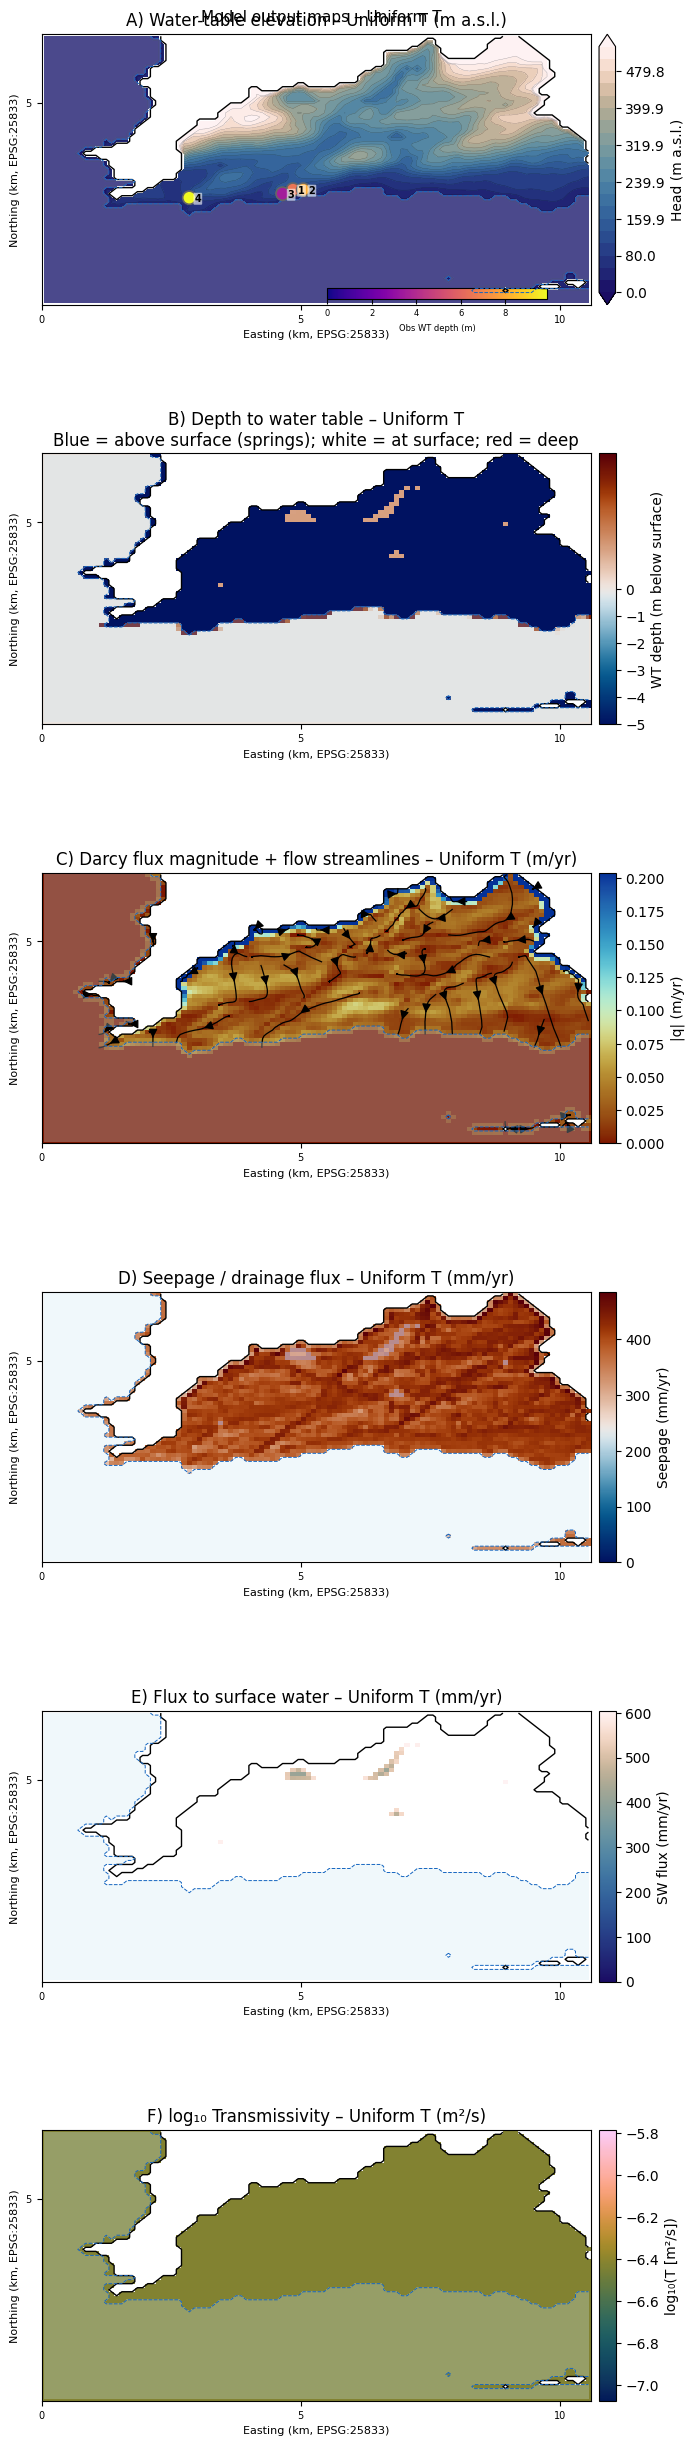

  Water budget — Uniform T
--------------------------------------------------------------
  Component                               mm/yr  Sign
--------------------------------------------------------------
  Recharge                                411.1   +
  Lake discharge                           -7.8   -
  River discharge                          -0.2   -
  Upland seepage (non-SW land)           -399.0   -
  Sea discharge (direct Darcy estimate)      -4.1   -
--------------------------------------------------------------
  Budget imbalance (should ≈ 0)            -0.0
  Active land area: 24.8 km²
  Sea discharge residual check: 4.0 mm/yr (Darcy: 4.1 mm/yr)


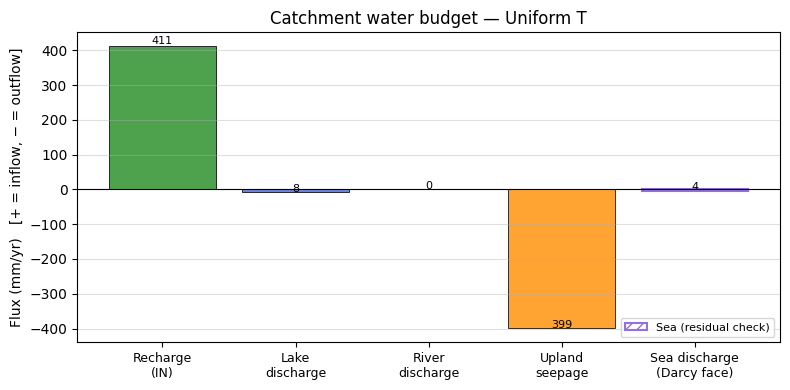

<Figure size 640x480 with 0 Axes>

In [65]:

# Full model output maps for the uniform-T calibration
plot_model_output(
    head_uniform, diag_uniform, best_hk_uniform, 'Uniform T',
    show_obs=eval_uniform if not eval_uniform.empty else None
)
plt.gcf().savefig(model_dir / 'figure_b1_model_output_uniform.png', dpi=300, bbox_inches='tight')
# Also keep the losing-reach diagnostic arrays for Part D comparison
drn_elev_u = diag_uniform['drn_elev']
below_wt_u = sw_cells & np.isfinite(head_uniform) & (head_uniform < drn_elev_u)


## Plot calibration quality - uniform T

The code below prdocues figures for the observed vs modelled water-table depths, gaining and losing surface-water cells.


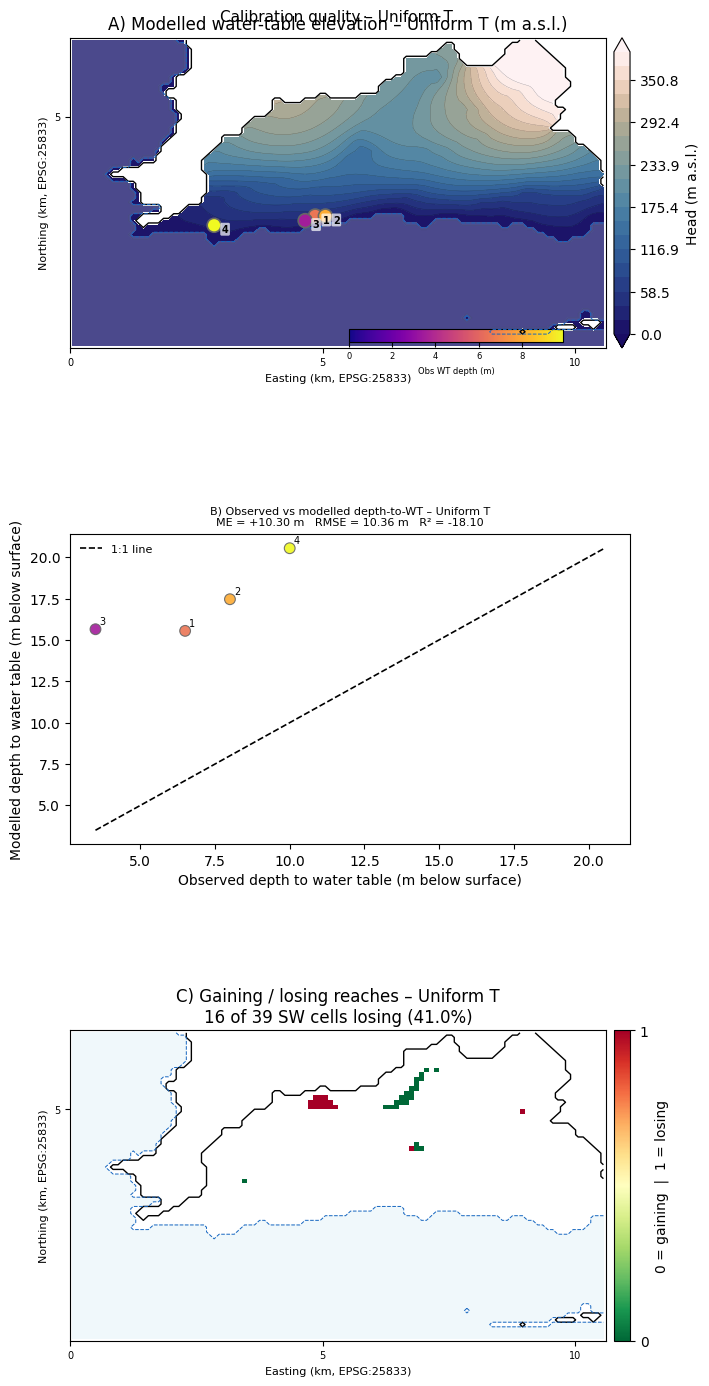


Modelled vs observed depth-to-water-table – Uniform T:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,14397,6.5,15.54,9.04
1,2,14396,8.0,17.46,9.46
2,3,14539,3.5,15.64,12.14
3,4,33467,10.0,20.54,10.54



Modelled vs observed depth-to-water-table – Uniform T:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,14397,6.5,15.54,9.04
1,2,14396,8.0,17.46,9.46
2,3,14539,3.5,15.64,12.14
3,4,33467,10.0,20.54,10.54


<Figure size 640x480 with 0 Axes>

In [44]:

# Calibration quality: map, scatter, residuals, gaining/losing reaches
plot_calibration_comparison(
    head_uniform, diag_uniform, eval_uniform,
    stats_uniform, targets_uniform, 'Uniform T'
)
plt.gcf().savefig(model_dir / 'figure_b2_calibration_uniform.png', dpi=300, bbox_inches='tight')

# Modelled vs observed depth-to-WT table (numbered wells)
if not eval_uniform.empty:
    print('\nModelled vs observed depth-to-water-table – Uniform T:')
    tbl = eval_uniform.copy()
    tbl['model_depth_m'] = tbl['dem_m'] - tbl['model_head_m']
    tbl['depth_resid_m'] = tbl['model_depth_m'] - tbl['obs_depth_m']
    tbl_disp = tbl[['well_no', 'station_id',
                     'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_disp.columns = ['Well #', 'Station ID',
                         'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_disp)


## Define cross-section transects

In addition to looking at maps it is often informative to look at cross-sections of the watertable and the land surface.

Below you can define start and end coordinates for two cross-sections. The code then construct figures for these cross-sections automatically and shows the topgorapohy, watertable and location of seepage and discharge to surface water bodies.

**Tips for choosing good transects:**
- Align sections roughly along the groundwater flow direction (upland → coast) to show the full head gradient.

**What to look for in the cross-section plots:**
- **Depth to WT**: shallower in valleys and near the coast, deeper in uplands.
- **Seepage zones** (WT at or above DEM): should coincide with rivers and lakes, not appear on dry hillslopes.
- **Slope of the water table**: steeper slopes = larger hydraulic gradient = faster groundwater flow.
- **Differences between models**: does geology K change the WT depth systematically in certain lithologies?

In [77]:
# ── User cross-section lines ──────────────────────────────────────────────
# Enter start and end coordinates (easting, northing in metres, EPSG:25833) for
# each cross-section you want to plot.
#
# How to pick good coordinates:
#   • Read easting and northing (in metres) off the map tick labels above.
#     Tick labels show kilometres; multiply by 1000 to get metres.
#   • Orient sections along the flow direction (high head → low head) to
#     show the saturated zone and discharge zone clearly.
#   • A coast-perpendicular section captures sea–land WT gradients.
#   • A section along a valley floor shows shallow WT and seepage zones.
#
# The defaults below span the full model domain.  The 1st section (A–B) runs
# W–E through the N–S midpoint; the 2nd section (C–D) runs N–S through the
# E–W midpoint.  Adjust the coordinates to focus on features of interest.

# Full model-domain extent from the Affine transform.
_x_min = transform.c
_x_max = transform.c + ncol * delc
_y_max = transform.f
_y_min = transform.f - nrow * delr
_x_mid = (_x_min + _x_max) / 2.0
_y_mid = (_y_min + _y_max) / 2.0

#x1_start, y1_start = _x_min, _y_mid
#x1_end,   y1_end   = _x_max, _y_mid
#x2_start, y2_start = _x_mid, _y_max
#x2_end,   y2_end   = _x_mid, _y_min

print('Default section endpoints (edit the coordinates below to change):')
print(f'  Section 1 (A-B, W-E): start ({x1_start:.0f}, {y1_start:.0f}), end ({x1_end:.0f}, {y1_end:.0f})')
print(f'  Section 2 (C-D, N-S): start ({x2_start:.0f}, {y2_start:.0f}), end ({x2_end:.0f}, {y2_end:.0f})')

# uncomment the following lines and edit the coordinates to define your own sections instead of the defaults above.
# replace ... below with the desired coordinates (easting, northing in metres, EPSG:25833)
x1_start, y1_start = 99628 , 9981286
x1_end,   y1_end   = 200233 , 7981286
x2_start, y2_start = 54931 , 2984638
x2_end,   y2_end   = 54931 , 2977935

user_xsection_endpoints = [
    {'label': 'Section 1 (A-B, W-E)',
     'start_xy': (x1_start, y1_start),
     'end_xy':   (x1_end, y1_end)},
    {'label': 'Section 2 (C-D, N-S)',
     'start_xy': (x2_start, y2_start),
     'end_xy':   (x2_end, y2_end)},
    # Add or remove entries as needed:
    # {'label': 'Section 3', 'start_xy': (x0, y0), 'end_xy': (x1, y1)},
]

# Build transect dicts from the endpoint coordinates.
user_transects = []
for ep in user_xsection_endpoints:
    try:
        tr = gwu.make_transect_from_endpoints(
            ep['start_xy'], ep['end_xy'],
            transform, delr, delc, active, label=ep['label'])
        user_transects.append(tr)
        km = tr['dist_m'][-1] / 1000.0
        print(f"  {tr['label']}: {len(tr['rows'])} active cells, "
              f"length {km:.1f} km")
    except ValueError as exc:
        print(f'  Warning [{ep["label"]}]: {exc}')

if not user_transects:
    print('No valid transects, check coordinates above.')
    print('Automatic section placement will be used as fallback.')

Default section endpoints (edit the coordinates below to change):
  Section 1 (A-B, W-E): start (99628, 9981286), end (200233, 7981286)
  Section 2 (C-D, N-S): start (54931, 2984638), end (54931, 2977935)
  Warning [Section 1 (A-B, W-E)]: Transect 'Section 1 (A-B, W-E)' contains fewer than 2 active cells. Check that the start/end coordinates lie within the active domain.
  Warning [Section 2 (C-D, N-S)]: Transect 'Section 2 (C-D, N-S)' contains fewer than 2 active cells. Check that the start/end coordinates lie within the active domain.
No valid transects, check coordinates above.
Automatic section placement will be used as fallback.


## Plot cross-sections – uniform T

The code below generates two cross-sections showing topography, modelled water table, and seepage zones for the uniform T model.

**What to look for:**
- Does the water table follow topography broadly, or is it very flat?
- Where does the WT reach or exceed the land surface? These should correspond to river/lake locations.
- How deep is the WT in upland areas? A very deep WT may indicate K is too high (water drains too fast).

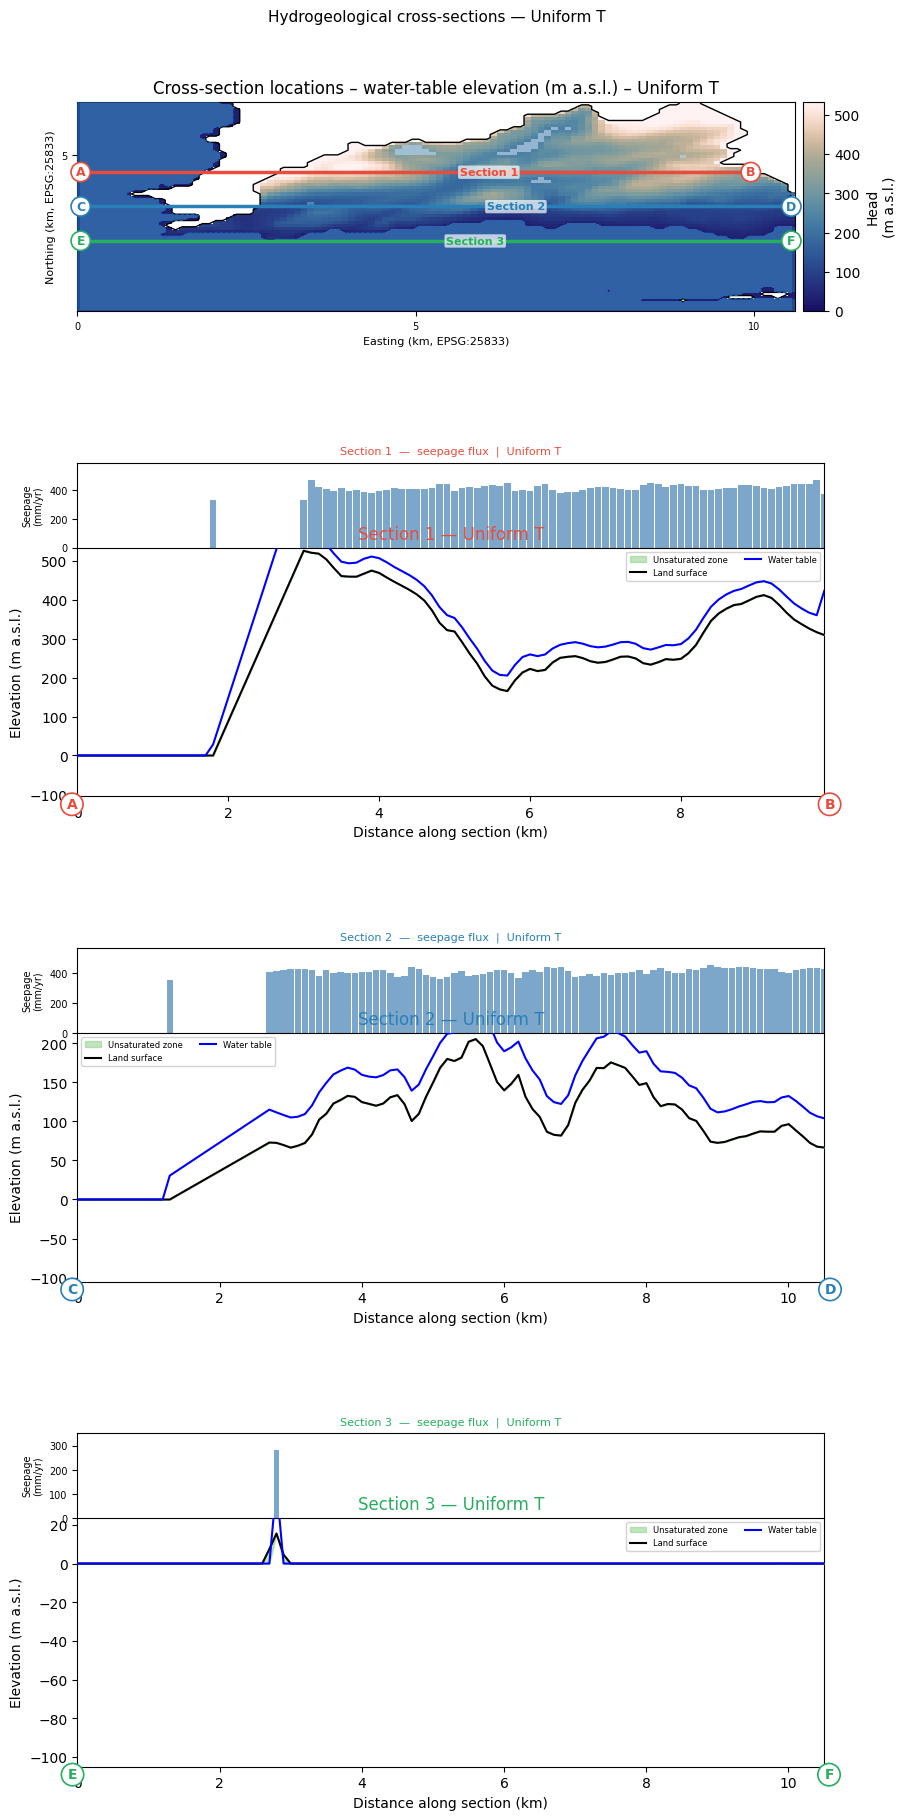

<Figure size 640x480 with 0 Axes>

In [69]:

# Cross-sections along student-defined lines – Uniform T
plot_cross_sections(head_uniform, diag_uniform, 'Uniform T',
                    transects=user_transects if user_transects else None)
plt.gcf().savefig(model_dir / 'figure_b3_cross_sections_uniform.png', dpi=300, bbox_inches='tight')


---
## Part D: Geology-Based Model with Spatially Variable Transmissivity

Transmissivity varies by several orders of magnitude between rock and soil types. Assuming a single uniform T everywhere ignores this variability. In Part D you assign different transmissivity values to different geology groups and check whether this improves the model.

**Two-stage workflow:**

1. **Stage D1: Define groups and assign transmissivity.** Read the geology legend, group unit IDs into categories (e.g. Quaternary deposits vs. bedrock), and assign a transmissivity T (m²/s) to each group. The starting point is the best uniform T from Part C. Change values group by group to explore heterogeneity.

2. **Stage D2: Run the model and optionally calibrate.** Run a forward model with the group T field. Optionally run automated calibration to find the best T per group.


### Stage D1: Geology units, calibration groups, and transmissivity assignment


In [47]:

# Read the geology legend and list all units present in the active model domain.
# The legend was created in Exercise 5A and includes both:
#   - Quaternary deposits (løsmasse, source = 'losmasse')
#   - Bedrock units (source = 'berggrunn_n50')
legend = pd.read_csv(data_dir / 'geology_legend.csv')
geo_unit_table = gwu.list_geology_units_in_domain(geo, legend, active)

pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_rows', 50)
print(f'{len(geo_unit_table)} geology units found in active model domain:')
print('  source=losmasse -> Quaternary deposits (K from gw_potential text)')
print('  source=berggrunn_n50 -> Bedrock units (K from lithology name)')
print()
display(geo_unit_table[['id', 'n_cells', 'source', 'deposit_type', 'gw_potential', 'k_default_m_s']])


15 geology units found in active model domain:
  source=losmasse -> Quaternary deposits (K from gw_potential text)
  source=berggrunn_n50 -> Bedrock units (K from lithology name)



,id,n_cells,source,deposit_type,gw_potential,k_default_m_s
0,0,3088,,(not in legend),,3.000000e-06
1,101,1606,berggrunn_n250,"Amfibolitt, lagdelt amfibolitt, amfibolrik gneis",NaN,5.000000e-08
2,107,1050,berggrunn_n250,"Granittisk ortogneis med bånd eller striper, nokre stader mig...",NaN,5.000000e-08
3,8,395,losmasse,"Morenemateriale, usammenhengende eller tynt dekke over berggr...",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
4,5,271,losmasse,"Hav-, fjord- og strandavsetning, usammenhengende eller tynt d...",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
5,10,237,losmasse,Tynt dekke av organisk materiale over berggrunn,Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
6,7,172,losmasse,"Morenemateriale, sammenhengende dekke, stedvis med stor mekti...",Antatt begrenset grunnvannspotensial,2.000000e-05
7,6,83,losmasse,"Marin strandavsetning, sammenhengende dekke",Antatt begrenset grunnvannspotensial,2.000000e-05
8,3,79,losmasse,Fyllmasse (antropogent materiale),Antatt ikke grunnvannspotensial i løsmassene,8.000000e-07
9,9,56,losmasse,Torv og myr,Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05


#### Stage D1: Assign transmissivity by geology group

The workflow has two steps in the cell below:

**Step 1 – Group geology units:**  
Assign each unit ID from the table above to a named group. The default auto-populates two groups:
- `quaternary`: all Quaternary deposit units (source = *losmasse*)
- `bedrock`: all bedrock units (source = *berggrunn\_n50*)

You can split these further (e.g. coarse vs. fine Quaternary), rearrange IDs between groups, or collapse everything into one group.

**Step 2 – Assign T per group:**  
Each group gets one transmissivity value T (m²/s). The starting value is `best_t_uniform` from Part C, so by default the model is identical to the uniform case. Change values and re-run to explore the effect of geological heterogeneity.

**Physical guidance (T = K × b, with b = `aquifer_thickness_m`):**

| Material | Typical K (m/s) | Typical T (m²/s) at b = 50 m |
|---|---|---|
| Gravel / coarse sand | 10⁻⁴ – 10⁻² | 5×10⁻³ – 0.5 |
| Medium to fine sand | 10⁻⁶ – 10⁻⁴ | 5×10⁻⁵ – 5×10⁻³ |
| Sandy till (Quaternary) | 10⁻⁷ – 10⁻⁵ | 5×10⁻⁶ – 5×10⁻⁴ |
| Fractured gneiss/granite (bedrock) | 10⁻⁸ – 10⁻⁶ | 5×10⁻⁷ – 5×10⁻⁵ |


Edit `geo_groups` and `T_by_group` in the cells below, then run it. A map of the resulting field is shown next.


In [72]:
# ── STUDENT EXERCISE: Define calibration groups and assign transmissivity ──────
#
# Step 1: Group the geology units.
# The default below auto-populates two groups from the legend table (Cell above).
# Edit geo_groups to customise the grouping for your catchment, e.g.:
geo_groups = {
       'quaternary': [2, 3, 4, 5, 6, 7, 8, 9, 10],   # unit IDs from the table above
       'bedrock':    [101, 102, 104, 106, 107],
   }

_q_ids  = sorted(geo_unit_table.loc[
    geo_unit_table['source'] == 'losmasse', 'id'].astype(int).tolist())
_b_ids  = sorted(geo_unit_table.loc[
    geo_unit_table['source'] == 'berggrunn_n250', 'id'].astype(int).tolist())
_all_ids   = set(int(i) for i in geo_unit_table['id'].astype(int))
_known_ids = set(_q_ids) | set(_b_ids)
_other_ids = sorted(_all_ids - _known_ids)

geo_groups = {
    'quaternary': _q_ids,    # Quaternary deposits (glacial till, moraine, alluvium)
    'bedrock':    _b_ids,    # Classified bedrock (gneiss, granite, schist, …)
}
if _other_ids:
    geo_groups['other'] = _other_ids  # Unclassified units

# If not all active unit IDs are listed, the model will raise an error.
# Set True only if you want unassigned units to fall back into the last group.
allow_unassigned_fallback = False

# ── Validation ─────────────────────────────────────────────────────────────────────────────
active_unit_ids   = set(np.unique(geo[active]).astype(int))
assigned_unit_ids = set(int(uid) for ids in geo_groups.values() for uid in ids)
missing_unit_ids  = sorted(active_unit_ids - assigned_unit_ids)

if missing_unit_ids and not allow_unassigned_fallback:
    raise ValueError(
        'Some active geology unit IDs are not assigned to any group: '
        f'{missing_unit_ids}. Add them to geo_groups or set '
        'allow_unassigned_fallback = True.'
    )

if missing_unit_ids and allow_unassigned_fallback:
    print('Note: the following unassigned units will fall back to the last group:')
    print(f'  {missing_unit_ids}')

# Build a group-index array: each active cell gets a number 0..n_groups-1
group_labels, group_names = gwu.make_k_by_geo_groups(
    geo, active, geo_groups, allow_fallback=allow_unassigned_fallback,
)

print('Calibration group summary:')
for i, name in enumerate(group_names):
    n_cells = int((group_labels == i).sum())
    ids_in_group = geo_groups.get(name, [])
    print(f'  Group {i + 1}: "{name}", {n_cells:,} active cells  '
          f'(unit IDs: {ids_in_group})')



Calibration group summary:
  Group 1: "quaternary", 1,298 active cells  (unit IDs: [2, 3, 4, 5, 6, 7, 8, 9, 10])
  Group 2: "bedrock", 1,512 active cells  (unit IDs: [101, 102, 104, 106, 107])
  Group 3: "other", 3,088 active cells  (unit IDs: [0])


In [84]:
# ── Step 2: Assign transmissivity per group ──────────────────────────────────────────
# Each group gets a transmissivity T (m²/s).
# Start from best_t_uniform (Part C) — identical to the uniform model.
# Change values step by step to explore the effect of geological heterogeneity.

T_by_group = {name: best_t_uniform for name in group_names}

# ── MODIFY BELOW: assign different T values per group (uncomment and adjust) ──
T_by_group['quaternary'] = 4.502e-05   # m²/s  <- changed this from best_t_uniform to 4.502e-05
T_by_group['bedrock']    = 3.312e-05   # m²/s  <- changed this from best_t_uniform to 3.312e-05

# ── Build the hk field (K = T / aquifer_thickness_m) ───────────────────────────
hk_geo_base = np.full_like(dem, 1e-12, dtype=float)
for i, name in enumerate(group_names):
    if name not in T_by_group:
        raise ValueError(
            f'Group "{name}" not found in T_by_group. '
            'Add an entry for every group.'
        )
    T_group = float(T_by_group[name])
    if T_group <= 0:
        raise ValueError(f'T for group "{name}" must be > 0 m²/s.')
    hk_geo_base[group_labels == i] = T_group / aquifer_thickness_m
hk_geo_base = np.where(active, hk_geo_base, 1e-12)

print('\nTransmissivity assigned per group:')
for name in group_names:
    T_val = T_by_group[name]
    K_val = T_val / aquifer_thickness_m
    print(f'  {name}: T = {T_val:.2e} m²/s  (K = {K_val:.2e} m/s)')
print(f'\nGeology K field (active cells):')
print(f'  min K = {hk_geo_base[active].min():.2e} m/s')
print(f'  max K = {hk_geo_base[active].max():.2e} m/s')
print(f'  mean K = {hk_geo_base[active].mean():.2e} m/s')


Transmissivity assigned per group:
  quaternary: T = 4.50e-05 m²/s  (K = 4.50e-07 m/s)
  bedrock: T = 3.31e-05 m²/s  (K = 3.31e-07 m/s)
  other: T = 3.70e-07 m²/s  (K = 3.70e-09 m/s)

Geology K field (active cells):
  min K = 3.70e-09 m/s
  max K = 4.50e-07 m/s
  mean K = 1.86e-07 m/s


## Map of assigned transmissivity field

Inspect the T/K field before running the model. A plausible map should show higher T in valley bottoms and Quaternary deposits, lower T in upland bedrock areas.


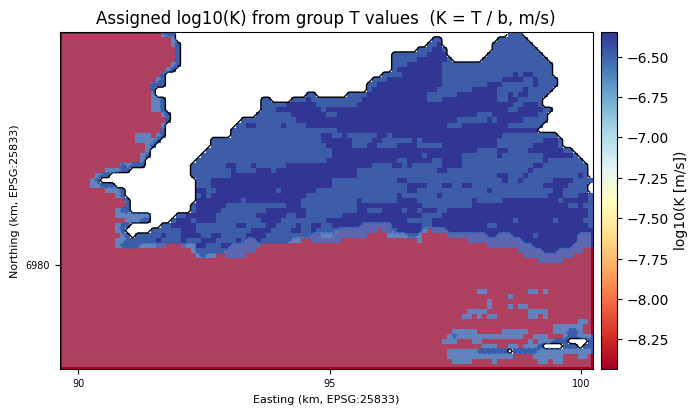

In [85]:
# Map of assigned K values (log10 scale) – check that the geology-based K field
# looks spatially reasonable before proceeding to calibration.
ph = _panel_h()
fig, ax = plt.subplots(1, 1, figsize=(7, ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.10)

_log_k = np.where(active, np.log10(np.maximum(hk_geo_base, 1e-12)), np.nan)
im_k = ax.imshow(_log_k, cmap='RdYlBu')
ax.set_title('Assigned log10(K) from group T values  (K = T / b, m/s)')
_cbar(im_k, ax, 'log10(K [m/s])')
add_map_ticks(ax)
add_map_overlays(ax)
fig.savefig(model_dir / 'figure_d1_geology_K_map.png', dpi=300, bbox_inches='tight')
plt.show()


### Stage D2: Run model with group transmissivity field

Run a forward model using the T values assigned in Stage D1. Compare with the uniform T result from Part C.

Optionally run automated calibration to find the best T per group (set `run_geo_calibration = True`). The optimiser searches directly in log₁₀(T) space; starting values come from `T_by_group`.


In [51]:
# ── Forward run with the group T field from Stage D1 ───────────────────────
geo_base_result = evaluate_candidate(hk_geo_base, obs_grid)
print('Group T model, forward run (no calibration):')
print(f"  Well depth RMSE      = {geo_base_result['obs_stats']['rmse']:.2f} m  [cal target]")
print(f"  SW head-deficit RMSE = {geo_base_result['target_stats']['sw_head_deficit_rmse_m']:.2f} m  [cal target]")
print(f"  R²                   = {geo_base_result['obs_stats']['r2']:.3f}  [diagnostic]")
print(f"  Loss = {geo_base_result['loss']:.3f}")
print(f"  (Uniform T loss was: {uniform_result['loss']:.3f})")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...
Group T model, forward run (no calibration):
  Well depth RMSE      = 10.36 m  [cal target]
  SW head-deficit RMSE = 10.77 m  [cal target]
  R²                   = -3.034  [diagnostic]
  Loss = 2.113
  (Uniform T loss was: 2.113)


## Optional: automated group T calibration

Set `run_geo_calibration = True` to run Nelder-Mead optimisation of T per group. The cell also assembles the final results and prints calibration statistics.


**Expected output (Stage D2):**
- Transmissivity and K summary printed per group.
- Forward-run RMSE, R², and combined loss; compare with uniform T result from Part C.
- If `run_geo_calibration = True`: best T values per group printed, followed by calibrated RMSE/R²/loss.
- Calibration quality maps, model output maps, and water budget shown.


In [78]:
# ── Optional: automated group T calibration ───────────────────────────────
# Set run_geo_calibration = True to search for the best T per group using
# Nelder-Mead optimisation. Starting values come from T_by_group (Stage D1).
run_geo_calibration = False

# Allowed T range (log10 space) for the calibration search.
_T_LOG_MIN = -8.0   # 1e-8 m²/s  (very low T)
_T_LOG_MAX =  0.0   # 1e0  m²/s  (very high T)


def build_hk_from_group_T(log10_T_vals):
    """
    Build an hk array from per-group log10(T) values.
    K = T / aquifer_thickness_m; log10_T values are clipped to valid range.
    """
    hk = np.full_like(dem, 1e-12, dtype=float)
    for i in range(len(group_names)):
        T_group = 10.0 ** np.clip(log10_T_vals[i], _T_LOG_MIN, _T_LOG_MAX)
        hk[group_labels == i] = T_group / aquifer_thickness_m
    return np.where(active, hk, 1e-12)


# Starting log10(T) values from Stage D1 T_by_group
_x0_log10_T = [np.log10(T_by_group[name]) for name in group_names]

if run_geo_calibration:
    _cache_geo = {}

    def _objective_geo(log10_T_vals):
        _key = tuple(np.round(np.asarray(log10_T_vals, dtype=float), 3))
        if _key not in _cache_geo:
            _hk = build_hk_from_group_T(log10_T_vals)
            _cache_geo[_key] = evaluate_candidate(_hk, obs_grid)['loss']
        return _cache_geo[_key]

    _res_g = minimize(
        _objective_geo,
        x0=_x0_log10_T,
        method='Nelder-Mead',
        options={'maxiter': 150, 'xatol': 0.05, 'fatol': 0.02},
    )
    best_hk_geo = build_hk_from_group_T(_res_g.x)
    print('Best T values found by calibration:')
    for gname, log10_T in zip(group_names, _res_g.x):
        T_cal = 10.0 ** np.clip(log10_T, _T_LOG_MIN, _T_LOG_MAX)
        K_cal = T_cal / aquifer_thickness_m
        print(f'  {gname}: T = {T_cal:.3e} m²/s  (K = {K_cal:.3e} m/s)')
else:
    best_hk_geo = build_hk_from_group_T(_x0_log10_T)
    print('Using T values from Stage D1 (set run_geo_calibration = True to optimise).')

geo_result  = evaluate_candidate(best_hk_geo, obs_grid)
head_geo    = geo_result['head']
diag_geo    = geo_result['diagnostics']
eval_geo    = geo_result['eval_df']
stats_geo   = geo_result['obs_stats']
targets_geo = geo_result['target_stats']

_T_best_geo = best_hk_geo * aquifer_thickness_m
print(f'\nFinal T range (active cells): '
      f'{_T_best_geo[active].min():.2e} – {_T_best_geo[active].max():.2e} m²/s')
print(f'Final K range (active cells): '
      f'{best_hk_geo[active].min():.2e} – {best_hk_geo[active].max():.2e} m/s')
print()
print('Geology model: calibration targets (enter the combined loss):')
print(f"  Well depth RMSE         : {stats_geo['rmse']:.2f} m")
print(f"  SW head-deficit RMSE    : {targets_geo['sw_head_deficit_rmse_m']:.2f} m")
print(f"  Combined calibration loss: {geo_result['loss']:.3f}")
print()
print('Geology model: diagnostics (not part of the calibration loss):')
print(f"  R²                      : {stats_geo['r2']:.3f}")
print(f"  Bias                    : {stats_geo['bias']:.2f} m")
print(f"  Seepage match fraction  : {targets_geo['seepage_match_fraction']:.3f}")
print(f"  Losing-reach fraction   : {targets_geo['below_wt_fraction']:.3f}")
print(f"  SW stage RMSE           : {targets_geo['surfacewater_stage_rmse_m']:.2f} m")
print()
print(f"Combined loss  geology : {geo_result['loss']:.3f}")
print(f"Combined loss  uniform : {uniform_result['loss']:.3f}")
print(f'Geology model improves combined loss: {geo_result["loss"] < uniform_result["loss"]}')

activation_geo = gwu.check_drain_activation(head_geo, diag_geo, sw, sea, active)
print('\nDrain activation (geology model):')
display(activation_geo)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package i

,feature,n_cells,n_drn_active,active_fraction
0,river,1,1,1.000000
1,lake,38,37,0.973684
2,sea,3419,0,1.000000


## Plot calibration quality – geology model

Calibration comparison and depth-to-WT table for the geology model.


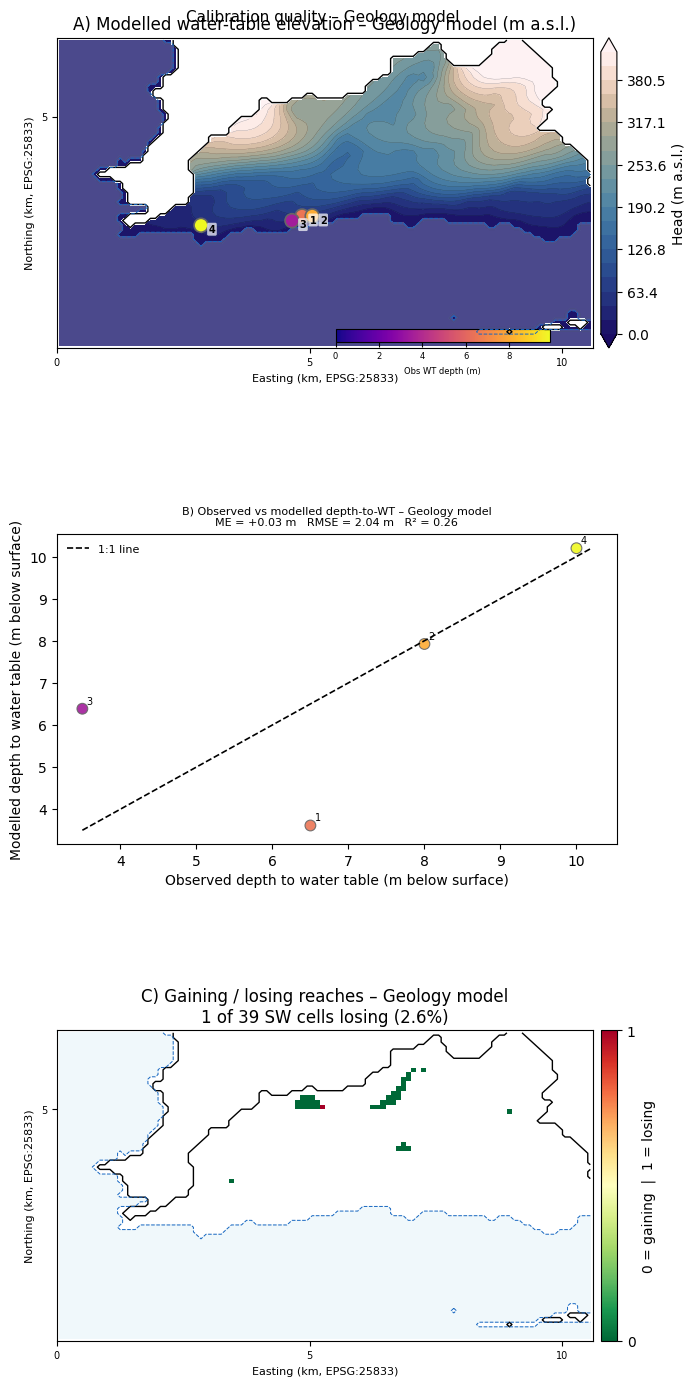


Modelled vs observed depth-to-water-table – Geology model:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,14397,6.5,3.61,-2.89
1,2,14396,8.0,7.92,-0.08
2,3,14539,3.5,6.39,2.89
3,4,33467,10.0,10.20,0.20



Modelled vs observed depth-to-water-table – Geology model:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,14397,6.5,3.61,-2.89
1,2,14396,8.0,7.92,-0.08
2,3,14539,3.5,6.39,2.89
3,4,33467,10.0,10.20,0.20


<Figure size 640x480 with 0 Axes>

In [86]:

# Calibration quality: geology model
plot_calibration_comparison(
    head_geo, diag_geo, eval_geo,
    stats_geo, targets_geo, 'Geology model'
)
plt.gcf().savefig(model_dir / 'figure_d4_calibration_geology.png', dpi=300, bbox_inches='tight')

# Modelled vs observed depth-to-WT table
if not eval_geo.empty:
    print('\nModelled vs observed depth-to-water-table – Geology model:')
    tbl_g = eval_geo.copy()
    tbl_g['model_depth_m'] = tbl_g['dem_m'] - tbl_g['model_head_m']
    tbl_g['depth_resid_m'] = tbl_g['model_depth_m'] - tbl_g['obs_depth_m']
    tbl_g_disp = tbl_g[['well_no', 'station_id',
                          'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_g_disp.columns = ['Well #', 'Station ID',
                            'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_g_disp)


## Head difference map – geology minus uniform

Map the difference in modelled water-table elevation between the geology and uniform T models. Red = geology predicts higher WT.


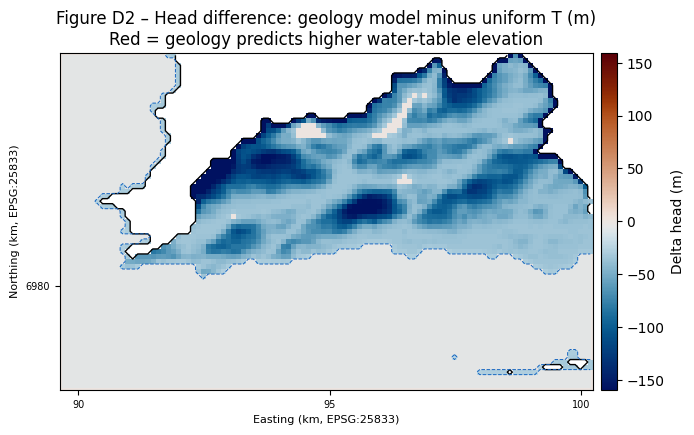

In [87]:
# Figure D2: Head difference (geology minus uniform)
drn_elev_g = diag_geo['drn_elev']
below_wt_g = sw_cells & np.isfinite(head_geo) & (head_geo < drn_elev_g)

ph = _panel_h()
fig, ax = plt.subplots(1, 1, figsize=(7, ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.10)

diff_map = np.where(active, head_geo - head_uniform, np.nan)
vlim = max(abs(np.nanpercentile(diff_map, 2)), abs(np.nanpercentile(diff_map, 98)))
im_diff = ax.imshow(diff_map, cmap=cmc.vik, vmin=-vlim, vmax=vlim)
ax.set_title('Figure D2 – Head difference: geology model minus uniform T (m)\n'
             'Red = geology predicts higher water-table elevation')
_cbar(im_diff, ax, 'Delta head (m)')
add_map_ticks(ax)
add_map_overlays(ax)
fig.savefig(model_dir / 'figure_d2_head_difference.png', dpi=300, bbox_inches='tight')
plt.show()


## Model output maps – geology model

Six-panel spatial overview for the geology-based calibration.


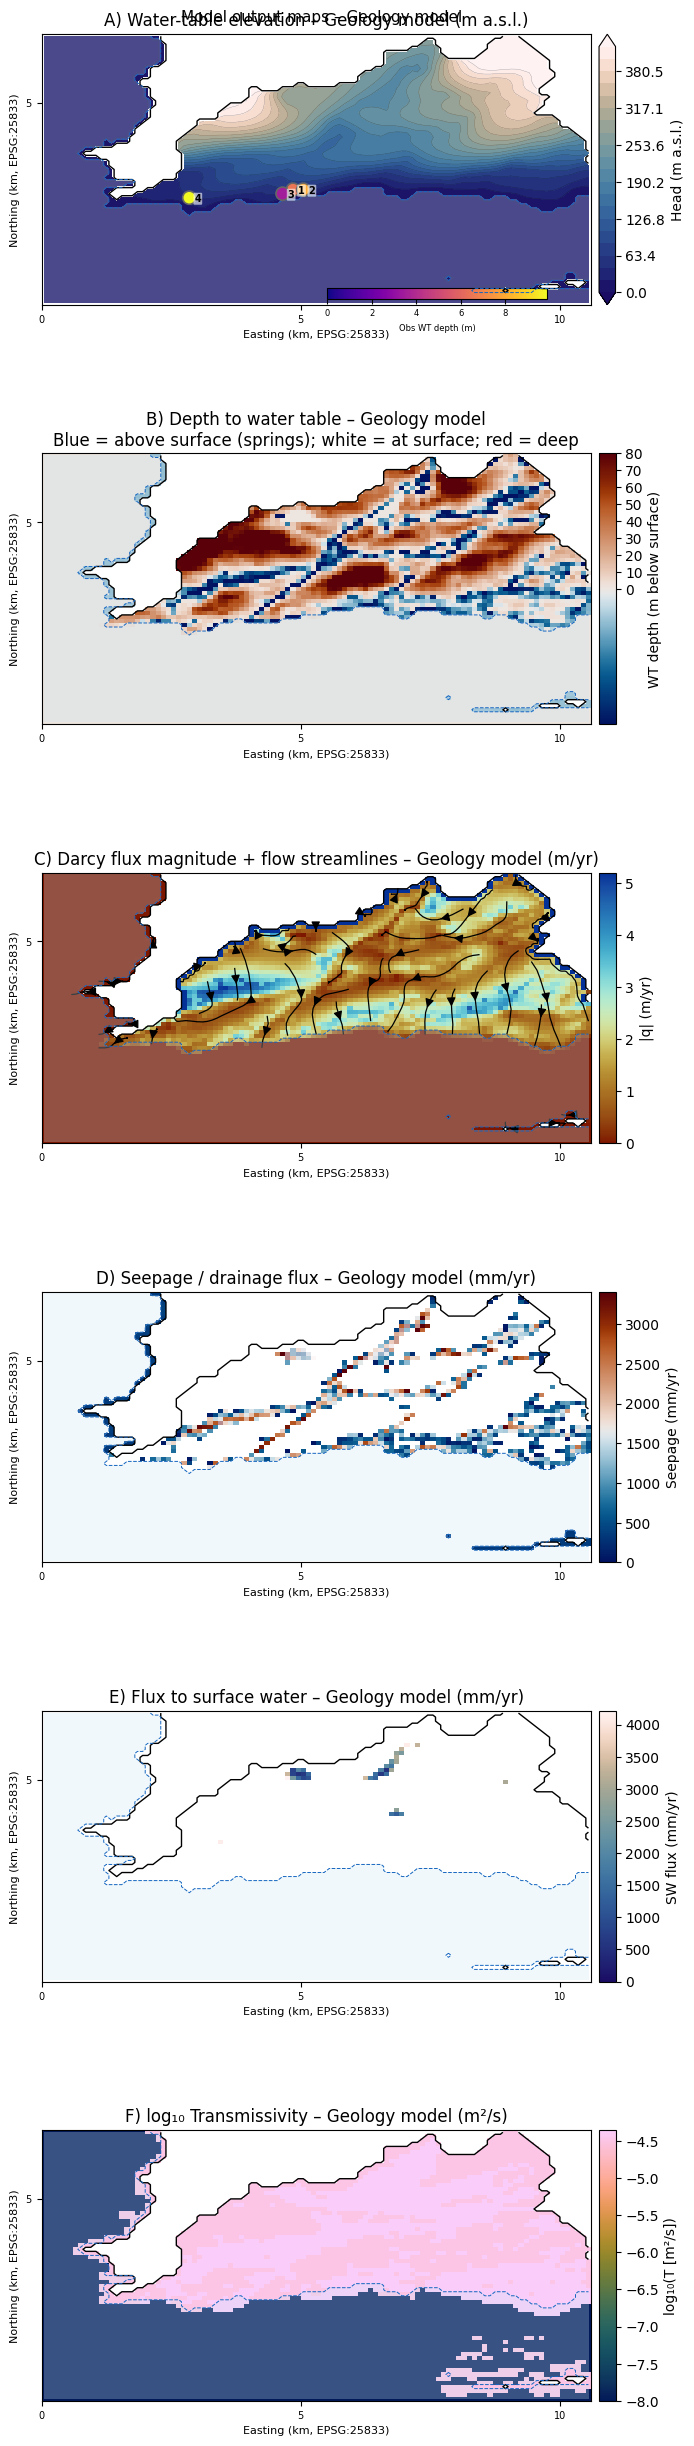

  Water budget — Geology model
--------------------------------------------------------------
  Component                               mm/yr  Sign
--------------------------------------------------------------
  Recharge                                411.1   +
  Lake discharge                          -30.3   -
  River discharge                          -1.7   -
  Upland seepage (non-SW land)           -335.1   -
  Sea discharge (direct Darcy estimate)     -55.8   -
--------------------------------------------------------------
  Budget imbalance (should ≈ 0)           -11.9
  Active land area: 24.8 km²
  Sea discharge residual check: 43.9 mm/yr (Darcy: 55.8 mm/yr)


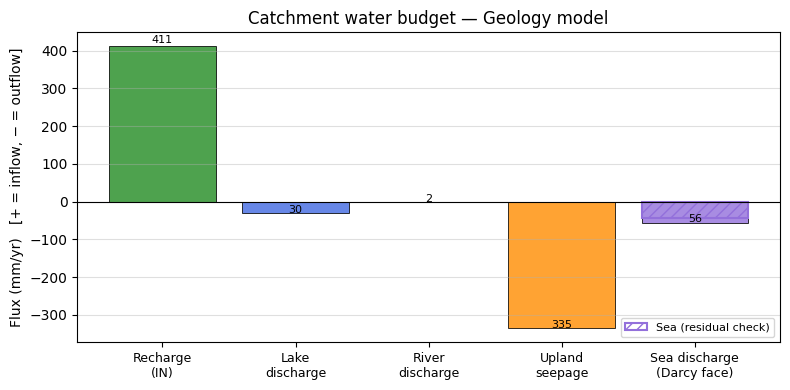

<Figure size 640x480 with 0 Axes>

In [88]:

# Full model output maps for the geology calibration
plot_model_output(
    head_geo, diag_geo, best_hk_geo, 'Geology model',
    show_obs=eval_geo if not eval_geo.empty else None
)
plt.gcf().savefig(model_dir / 'figure_d3_model_output_geology.png', dpi=300, bbox_inches='tight')


## Plot cross-sections – geology model

Cross-sections along the same transects as the uniform T model, for direct side-by-side comparison.

**Compare with the uniform T sections above:**
- Does the geology model produce shallower or deeper WT in sediment-filled valleys?
- Do seepage zones expand or contract relative to the uniform T model?
- In bedrock uplands, does the lower K create a steeper WT gradient?

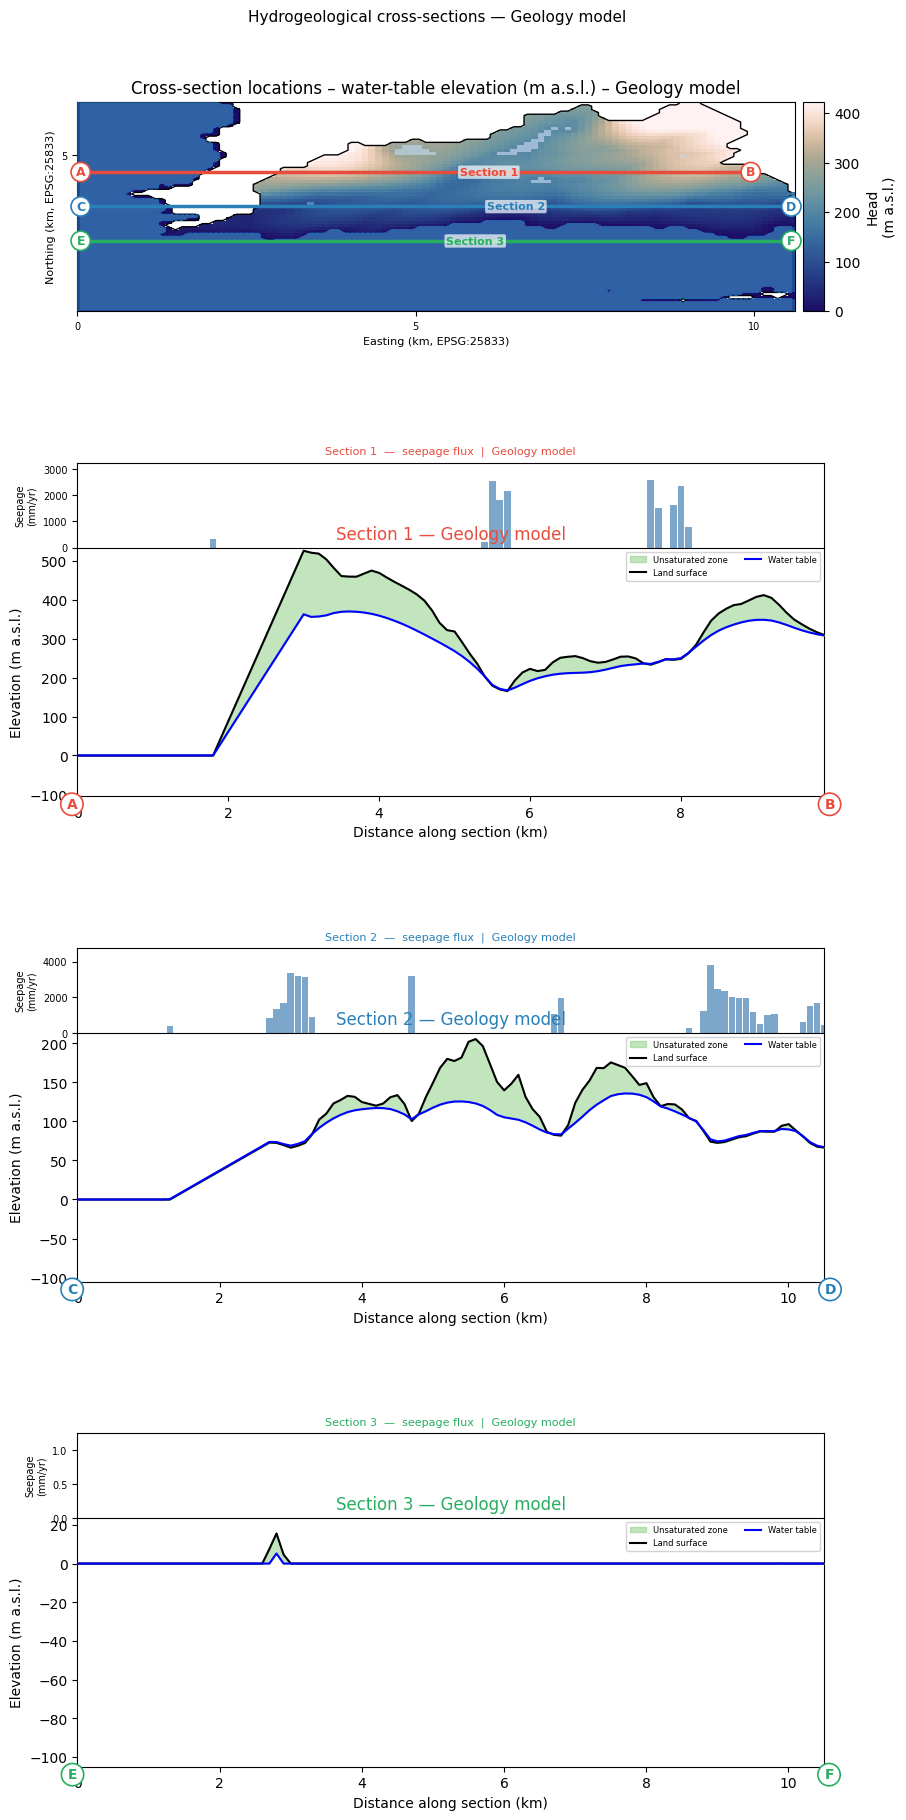

<Figure size 640x480 with 0 Axes>

In [89]:

# Cross-sections along student-defined lines – Geology model
plot_cross_sections(head_geo, diag_geo, 'Geology model',
                    transects=user_transects if user_transects else None)
plt.gcf().savefig(model_dir / 'figure_d5_cross_sections_geology.png', dpi=300, bbox_inches='tight')



---
## Calibration Summary

Side-by-side comparison of all calibrations run so far.

**How to read the table:**
- **Well depth RMSE** and **SW head-deficit RMSE** are the two calibration targets that enter the combined loss. Both are in metres; lower is better.
  - Well depth RMSE: for a catchment-scale model with sparse borehole data, values of 1–5 m are typical; < 2 m is good.
  - SW head-deficit RMSE: zero means all river/lake cells are gaining (ideal); positive values indicate that the water table is below the streambed at some cells.
- **Combined loss** is the primary deciding metric. Prefer the model with the lower combined loss.
- The rows marked **[diagnostic]** are reported for interpretation but do **not** enter the optimisation:
  - **R²** > 0.7 is generally acceptable; negative values indicate the model is worse than simply using the mean observed head everywhere.
  - **Bias**: a positive bias means the model over-predicts head (water table too high); negative means too low.
  - **Seepage match fraction**: fraction of SW cells where the model predicts gaining conditions (head ≥ streambed). Aim for > 0.8.
  - **Losing-reach fraction**: fraction of SW cells where the model predicts the water table is below the streambed. Ideally close to zero.
- **Small differences (< ~5–10 %)** in RMSE or R² between models are not meaningful given borehole observation uncertainty and coarse model resolution.

In [90]:

def _fmt(d, key, fmt='.2f'):
    v = d.get(key, np.nan) if d else np.nan
    try:
        fv = float(v)
    except (TypeError, ValueError):
        return str(v)
    return f'{fv:{fmt}}' if np.isfinite(fv) else 'n/a'

rows = {
    'Metric': [
        # ── Calibration targets (enter the combined loss) ──
        'Well depth RMSE (m)  [CAL TARGET]',
        'SW head-deficit RMSE (m)  [CAL TARGET]',
        'Combined loss',
        # ── Diagnostics (reported but not in the loss) ──
        'R²  [diagnostic]',
        'Bias (m)  [diagnostic]',
        'Seepage match fraction  [diagnostic]',
        'Losing-reach fraction  [diagnostic]',
    ],
    'Uniform T': [
        _fmt(stats_uniform, 'rmse'),
        _fmt(targets_uniform, 'sw_head_deficit_rmse_m'),
        f"{uniform_result['loss']:.3f}",
        _fmt(stats_uniform, 'r2', '.3f'),
        _fmt(stats_uniform, 'bias'),
        _fmt(targets_uniform, 'seepage_match_fraction', '.3f'),
        _fmt(targets_uniform, 'below_wt_fraction', '.3f'),
    ],
    'Geology model': [
        _fmt(stats_geo, 'rmse'),
        _fmt(targets_geo, 'sw_head_deficit_rmse_m'),
        f"{geo_result['loss']:.3f}",
        _fmt(stats_geo, 'r2', '.3f'),
        _fmt(stats_geo, 'bias'),
        _fmt(targets_geo, 'seepage_match_fraction', '.3f'),
        _fmt(targets_geo, 'below_wt_fraction', '.3f'),
    ],
}

summary = pd.DataFrame(rows)
display(summary)


,Metric,Uniform T,Geology model
0,Well depth RMSE (m) [CAL TARGET],44.58,2.04
1,SW head-deficit RMSE (m) [CAL TARGET],0.00,0.11
2,Combined loss,4.458,0.215
3,R² [diagnostic],-73.618,0.843
4,Bias (m) [diagnostic],44.55,-0.03
5,Seepage match fraction [diagnostic],1.000,0.974
6,Losing-reach fraction [diagnostic],0.000,0.026



---
## Save Calibration Results for Exercise 5C

The best calibrated K field and all required grid arrays are saved to a `.npz` file and a NetCDF dataset. Exercise 5C loads these files to run flooding and pumping scenarios without repeating the calibration.

**What to do:**
1. Look at the combined loss values printed after Parts C and D above.
2. Set `save_model` in the cell below to `'uniform'`, `'geology'`, or `'auto'`.
   - `'uniform'` — saves the uniform-T model from Part C.
   - `'geology'` — saves the geology K model from Part D.
   - `'auto'` — automatically picks whichever has the lower combined loss (only works if you completed Part D).
3. If you skipped Part D, leave `save_model = 'uniform'`.

**Check:** confirm that the printed file path ends inside your `data/model_input/` directory (or your Google Drive folder on Colab) before moving to Exercise 5C.

In [91]:
# ── Choose which calibration to save for Exercise 5C ─────────────────────────
# Review the combined loss values printed after Parts C and D, then set:
#   'uniform' – save the uniform-T model (Part C)
#   'geology' – save the geology K model  (Part D)
#   'auto'    – automatically pick whichever has the lower loss
#               (only works if you completed Part D; use 'uniform' if you skipped it)
save_model = 'uniform'   # <-- change to 'geology' or 'auto' after reviewing losses above

_geo_done = 'geo_result' in dir()   # True only if Part D was run

if save_model == 'geology':
    if not _geo_done:
        raise RuntimeError(
            "save_model = 'geology' but Part D has not been run yet. "
            "Run Part D first, or set save_model = 'uniform'."
        )
    hk_to_save   = best_hk_geo
    head_to_save = head_geo
    diag_to_save = diag_geo
    label_saved  = 'geology'
elif save_model == 'auto':
    if not _geo_done:
        raise RuntimeError(
            "save_model = 'auto' but Part D has not been run yet. "
            "Run Part D first, or set save_model = 'uniform'."
        )
    if geo_result['loss'] < uniform_result['loss']:
        hk_to_save   = best_hk_geo
        head_to_save = head_geo
        diag_to_save = diag_geo
        label_saved  = 'geology'
    else:
        hk_to_save   = best_hk_uniform
        head_to_save = head_uniform
        diag_to_save = diag_uniform
        label_saved  = 'uniform'
else:  # 'uniform'
    hk_to_save   = best_hk_uniform
    head_to_save = head_uniform
    diag_to_save = diag_uniform
    label_saved  = 'uniform'

if _geo_done:
    print(f'Loss – uniform T: {uniform_result["loss"]:.3f}  |  '
          f'geology K: {geo_result["loss"]:.3f}')
else:
    print(f'Loss – uniform T: {uniform_result["loss"]:.3f}  '
          f'(geology model not run)')
print(f'Saving: {label_saved}')

# Save legacy .npz file for Exercise 5C
cal_output = data_dir / 'calibrated_hk.npz'
np.savez(
    cal_output,
    best_hk               = hk_to_save,
    dem                   = dem,
    sw                    = sw,
    sea                   = sea,
    active                = active,
    rch                   = rch,
    delr                  = np.array([delr]),
    delc                  = np.array([delc]),
    nrow                  = np.array([nrow]),
    ncol                  = np.array([ncol]),
    aquifer_thickness_m           = np.array([aquifer_thickness_m]),
    sea_level_m                   = np.array([sea_level_m]),
    default_drain_bed_k_m_s       = np.array([default_drain_bed_k_m_s]),
    default_drain_bed_thickness_m = np.array([default_drain_bed_thickness_m]),
    drain_coupling_depth_m        = np.array([drain_coupling_depth_m]),
)
print(f'Legacy .npz saved to {cal_output}')

# Save full results as NetCDF for analysis and Exercise 5C
x_coords = np.array([transform.c + (j + 0.5) * delr for j in range(ncol)])
y_coords = np.array([transform.f - (i + 0.5) * delc for i in range(nrow)])

# Compute seepage map for uniform calibration (always available)
_sw_arr_nc  = np.where(sw_cells, 1, 0)
_sea_int_nc = sea.astype(int)
seep_unif_s = gwu.seepage_flux_stats(
    diag_uniform['drn_flux'], active, _sw_arr_nc, _sea_int_nc, delr, delc)

# Build dataset variables; geology arrays are only included when Part D was run
_nc_vars = {
    'head_uniform': (
        ['y', 'x'],
        np.where(active, head_uniform, np.nan).astype(np.float32),
        {'long_name': 'Modelled water-table head - uniform T', 'units': 'm a.s.l.'}),
    'best_hk': (
        ['y', 'x'],
        hk_to_save.astype(np.float32),
        {'long_name': 'Saved hydraulic conductivity', 'units': 'm/s'}),
    'dem': (
        ['y', 'x'],
        dem.astype(np.float32),
        {'long_name': 'Land-surface elevation', 'units': 'm a.s.l.'}),
    'active': (
        ['y', 'x'],
        active.astype(np.uint8),
        {'long_name': 'Active model domain (1 = active)'}),
    'sw': (
        ['y', 'x'],
        sw.astype(np.int16),
        {'long_name': 'Surface water type (0=none,1=lake,2=river,3=sea)'}),
    'sea': (
        ['y', 'x'],
        sea.astype(np.int16),
        {'long_name': 'Sea mask (1 = sea)'}),
    'geology': (
        ['y', 'x'],
        geo.astype(np.int16),
        {'long_name': 'Geology unit ID'}),
    'recharge_mm_yr': (
        ['y', 'x'],
        np.where(active, rch_mm_yr, np.nan).astype(np.float32),
        {'long_name': 'Effective recharge rate', 'units': 'mm/yr'}),
    'seepage_uniform_mm_yr': (
        ['y', 'x'],
        seep_unif_s['seepage_map_mm_yr'].astype(np.float32),
        {'long_name': 'Seepage flux - uniform T', 'units': 'mm/yr'}),
}

if _geo_done:
    seep_geo_s = gwu.seepage_flux_stats(
        diag_geo['drn_flux'], active, _sw_arr_nc, _sea_int_nc, delr, delc)
    _nc_vars['head_geology'] = (
        ['y', 'x'],
        np.where(active, head_geo, np.nan).astype(np.float32),
        {'long_name': 'Modelled water-table head - geology K', 'units': 'm a.s.l.'})
    _nc_vars['seepage_geology_mm_yr'] = (
        ['y', 'x'],
        seep_geo_s['seepage_map_mm_yr'].astype(np.float32),
        {'long_name': 'Seepage flux - geology K', 'units': 'mm/yr'})

ds = xr.Dataset(
    _nc_vars,
    coords={
        'x': (['x'], x_coords, {'units': 'm', 'long_name': 'Easting EPSG:25833'}),
        'y': (['y'], y_coords, {'units': 'm', 'long_name': 'Northing EPSG:25833'}),
    },
    attrs={
        'title': 'Exercise 5B - calibrated steady-state groundwater model outputs',
        'crs': 'EPSG:25833',
        'cell_size_m': float(delr),
        'aquifer_thickness_m': float(aquifer_thickness_m),
        'sea_level_m': float(sea_level_m),
        'best_calibration': label_saved,
    },
)

nc_path = data_dir / 'exercise5_model_outputs.nc'
ds.to_netcdf(nc_path)
print(f'NetCDF saved to {nc_path}')
print(ds)


Loss – uniform T: 4.458  |  geology K: 0.215
Saving: uniform
Legacy .npz saved to /content/drive/MyDrive/GEOV212_model_input/calibrated_hk.npz
NetCDF saved to /content/drive/MyDrive/GEOV212_model_input/exercise5_model_outputs.nc
<xarray.Dataset> Size: 250kB
Dimensions:                (y: 67, x: 106)
Coordinates:
  * y                      (y) float64 536B 6.985e+06 6.984e+06 ... 6.978e+06
  * x                      (x) float64 848B 8.968e+04 8.978e+04 ... 1.002e+05
Data variables:
    head_uniform           (y, x) float32 28kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    best_hk                (y, x) float32 28kB 3.701e-09 3.701e-09 ... 3.701e-09
    dem                    (y, x) float32 28kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    active                 (y, x) uint8 7kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    sw                     (y, x) int16 14kB 3 3 3 3 3 3 3 3 ... 3 3 3 3 3 3 3 3
    sea                    (y, x) int16 14kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    geology                (y, x)


---
## Part E (Optional): Groundwater Baseflow Routing

This section routes the **groundwater baseflow** (seepage/drainage flux) from the steady-state model downstream along the DEM topography. The result is a map of *accumulated groundwater baseflow*, how much groundwater discharge collects at each point in the landscape if it all flows downhill from where it emerges.

### What this is - and what it is not

- **This is baseflow only.** It uses the drain flux (`drn_flux`) from the MODFLOW model as the source term, groundwater that seeps to the land surface. It does **not** include direct precipitation, snowmelt, or surface runoff.
- **This is a kinematic routing.** Water follows the steepest-descent path on the DEM (D8 algorithm). There is no channel storage, no evaporation from streams, and no infiltration back into the ground.
- **The result shows where baseflow converges.** Valley bottoms, lake inlets, and coastal outlets will show the highest accumulated baseflow.

### Method: D8 single-flow-direction routing

1. **Flow direction (D8):** For each land cell, identify the one of eight neighbours (N, NE, E, SE, S, SW, W, NW) with the steepest downward slope. Water is routed entirely to that neighbour. Flat cells and sinks are filled before routing.
2. **Seepage source term:** Each active cell contributes its `drn_flux` (m³/s) as baseflow entering the surface network at that point.
3. **Flow accumulation:** Traverse cells in upstream-to-downstream order. Each cell receives the accumulated flux of all upslope cells, then adds its own seepage before passing the total downstream.
4. **Output:** `baseflow_acc_m3s`: accumulated baseflow (m³/s) at each cell, representing the total groundwater contribution to streamflow at that location.

> **Note on D8 vs. D-infinity:** D8 forces all flow into one direction and can produce unrealistically narrow flow paths on gentle slopes. D-infinity (Tarboton 1997) distributes flow across two neighbours. D8 is used here because it is conceptually simpler and sufficient for catchment-scale educational purposes.

### How to read the map

- **High values (warm colours)** = major baseflow-fed channels or lake inlets, places where a lot of groundwater converges.
- **Low values (cool colours)** = hillslopes or ridge-tops, little or no upstream baseflow contribution.
- **Only cells above the perennial-stream cutoff are shown.** The parameter `baseflow_perennial_cutoff_ls` (default 0.5 L/s) sets the minimum accumulated baseflow displayed. Cells below this threshold are hidden. Raise the value to focus on the main channels; lower it to also reveal smaller or intermittent flow paths.
- **Baseflow stops at the coastline.** Sea cells are treated as flow sinks: accumulated flow drains into the sea rather than being routed through or beyond it. This gives a physically correct picture of groundwater discharge to the coast.
- The **observed river and lake network** from Exercise 5A is overlaid in blue on both maps. Where the modelled high-accumulation cells align with the observed network, the model correctly predicts where groundwater discharges to surface water. Mismatches may indicate overestimated seepage in uplands, an inaccurate DEM sink-fill, or areas where groundwater gradients diverge from surface topography.
- Compare the uniform T and geology model routing maps: does accounting for geology change the spatial pattern of baseflow? Do the high-accumulation zones shift closer to, or further from, the observed rivers?


In [92]:
# ── Part E control ─────────────────────────────────────────────────────────
# Set to True to run the baseflow routing analysis.
# Requires Parts C and D (diag_uniform, diag_geo) to have been computed.
RUN_BASEFLOW_ROUTING = True

# Minimum accumulated baseflow to show in the map (L/s).
# Cells with accumulated baseflow below this threshold are hidden (shown as
# background). Increase this value to show only larger perennial streams;
# decrease it to also show intermittent or ephemeral flow paths.
baseflow_perennial_cutoff_ls = 1.0


In [93]:
# ── Part E: Helper function definitions ─────────────────────────────────────
#
# This cell implements D8 flow-direction + seepage-weighted flow accumulation
# using only NumPy and SciPy (no external terrain-analysis libraries needed).
#
# Variables used from earlier cells:
#   dem          – land-surface elevation array (nrow × ncol), NaN outside domain
#   active       – boolean mask of active model cells
#   diag_uniform – diagnostics dict from the uniform-T calibration
#   diag_geo     – diagnostics dict from the geology-based calibration
#   delr, delc   – cell dimensions (m)
#   nrow, ncol   – grid dimensions
#   transform    – affine transform of the model grid (rasterio Affine)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as _mlines
import json as _json
from pathlib import Path
from affine import Affine as _Affine

# ── 1. Baseflow routing via pysheds ───────────────────────────────────────────
# pysheds (conda install conda-forge::pysheds) provides robust, vectorised
# D8 flow-direction and weighted flow-accumulation, much faster than a
# pure-Python loop for larger grids.
def compute_baseflow_routing(dem, active, sea, seepage_m3s):
    """
    Condition the DEM, compute D8 flow direction, and accumulate seepage
    flux downstream using pysheds.

    Steps
    -----
    1. Write the masked DEM to a temporary GeoTIFF.  Sea cells are set to
       nodata so that pysheds treats the coastline as a flow outlet: baseflow
       is collected by the sea rather than routed through or beyond it.
    2. Fill pits and depressions; resolve flat areas (pysheds conditioning).
    3. Compute D8 flow directions.
    4. Accumulate seepage_m3s as downstream weights.

    Parameters
    ----------
    dem         : 2-D float array  – land-surface elevation (m); NaN outside domain
    active      : 2-D bool array   – True for cells inside the model domain
    sea         : 2-D int/bool array – 1 (or True) for sea / constant-head cells
    seepage_m3s : 2-D float array  – per-cell groundwater seepage (m³/s, ≥ 0)

    Returns
    -------
    acc : 2-D float array – accumulated baseflow (m³/s); zero outside the domain

    Notes
    -----
    Uses the module-level ``transform`` (affine) variable defined earlier in
    this notebook to georeference the temporary raster.
    """
    import tempfile
    import os
    import rasterio
    from pysheds.grid import Grid
    from pysheds.view import Raster as _PyShedsRaster

    _NODATA = -9999.0
    # Mask out sea cells so pysheds treats the coastline as a flow outlet.
    # Without this, D8 routing would continue through (or beyond) the sea,
    # producing unrealistic flow paths and inflated downstream accumulation.
    land_cells = active & ~(sea == 1)
    dem_write = np.where(land_cells, dem, _NODATA).astype('float32')

    # Write DEM to a temporary GeoTIFF (pysheds reads from raster files)
    _fd, _path = tempfile.mkstemp(suffix='.tif')
    os.close(_fd)
    try:
        with rasterio.open(
            _path, 'w', driver='GTiff',
            height=dem_write.shape[0], width=dem_write.shape[1],
            count=1, dtype='float32',
            crs='EPSG:25833', transform=transform, nodata=_NODATA,
        ) as _dst:
            _dst.write(dem_write, 1)

        # Condition the DEM
        grid  = Grid.from_raster(_path)
        dem_r = grid.read_raster(_path)
        dem_r = grid.fill_pits(dem_r)
        dem_r = grid.fill_depressions(dem_r)
        dem_r = grid.resolve_flats(dem_r)

        # D8 flow direction (standard ESRI encoding)
        _dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
        fdir = grid.flowdir(dem_r, dirmap=_dirmap)

        # Weighted accumulation: route seepage downstream
        _seepage = np.where(land_cells, np.maximum(seepage_m3s, 0.0), 0.0).astype('float32')
        _weights = _PyShedsRaster(_seepage, viewfinder=fdir.viewfinder)
        acc = grid.accumulation(fdir, weights=_weights, dirmap=_dirmap)

        return np.where(land_cells, np.asarray(acc), 0.0)
    finally:
        os.unlink(_path)


# ── 5. Geometry helpers for NVE observed network overlay ─────────────────────
def _geom_to_pixel_xy(geom_coords, transform):
    """Convert a list of (x, y) map coordinates to (col, row) pixel coordinates."""
    inv = ~transform
    return [inv * (x, y) for x, y in geom_coords]

def _collect_line_segments(geometry, transform):
    """
    Yield lists of (col, row) tuples for every LineString or ring in a geometry.
    Handles LineString, MultiLineString, Polygon, MultiPolygon.
    """
    gtype = geometry['type']
    if gtype == 'LineString':
        yield _geom_to_pixel_xy(geometry['coordinates'], transform)
    elif gtype == 'MultiLineString':
        for ring in geometry['coordinates']:
            yield _geom_to_pixel_xy(ring, transform)
    elif gtype == 'Polygon':
        # exterior ring only
        yield _geom_to_pixel_xy(geometry['coordinates'][0], transform)
    elif gtype == 'MultiPolygon':
        for poly in geometry['coordinates']:
            yield _geom_to_pixel_xy(poly[0], transform)


# ── 6. Plot helpers ─────────────────────────────────────────────────────────
def _overlay_observed_network(ax, river_color="steelblue", lake_color="royalblue"):
    """Draw observed river lines and lake outlines on an imshow() axes."""
    for seg in _river_segments:
        xs = [p[0] for p in seg]
        ys = [p[1] for p in seg]
        ax.plot(xs, ys, color=river_color, linewidth=1.5, alpha=0.8,
                label='_nolegend_')
    for seg in _lake_segments:
        xs = [p[0] for p in seg]
        ys = [p[1] for p in seg]
        ax.fill(xs, ys, color=lake_color, alpha=0.4)
        ax.plot(xs, ys, color=lake_color, linewidth=1.5, alpha=0.8,
                label='_nolegend_')


def _plot_baseflow_acc(acc_ls, active_mask, title, ax, cutoff_ls=0.5, cmap=cmc.imola, river_obs_color="gray", lake_obs_color="lightgrey"):
    """Plot accumulated baseflow on a log10 scale with observed network overlay.

    Parameters
    ----------
    acc_ls      : 2-D array  – accumulated baseflow in L/s
    active_mask : 2-D bool   – True for cells to include
    title       : str        – axes title
    ax          : matplotlib Axes
    cutoff_ls   : float      – minimum baseflow to display (L/s); cells below
                               this threshold are hidden (shown as background).
                               Default 0.5 L/s (perennial-stream threshold).
    """

    tick_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    tick_labs = ['0.001', '0.01', '0.1', '1', '10', '100', '1000']

    plot_arr = np.where(active_mask & (acc_ls >= cutoff_ls), np.log10(acc_ls + 1e-9), np.nan)
    im = ax.imshow(plot_arr, cmap=cmap, interpolation='nearest', vmax=np.log10(tick_vals[-1]))
    _overlay_observed_network(ax, river_color=river_obs_color, lake_color=lake_obs_color)
    ax.set_title(title)
    # Colourbar with labelled ticks in L/s
    from matplotlib.ticker import FuncFormatter
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    log_ticks = [np.log10(v) for v in tick_vals]
    cb.set_ticks(log_ticks)
    cb.set_ticklabels(tick_labs)
    cb.set_label(f'Accumulated baseflow (L/s, ≥{cutoff_ls} L/s shown)', fontsize=8)
    ax.set_xlabel('Column index', fontsize=8)
    ax.set_ylabel('Row index', fontsize=8)
    return im


In [94]:
# ── Part E: Run baseflow routing ─────────────────────────────────────────────
if not RUN_BASEFLOW_ROUTING:
    print('Baseflow routing skipped (RUN_BASEFLOW_ROUTING = False).')
else:
    # ── 1. Extract seepage and route downstream (pysheds D8 accumulation) ────────
    # Non-negative seepage flux from each calibration (m³/s per cell)
    seepage_uniform = np.where(active, np.maximum(diag_uniform['drn_flux'], 0.0), 0.0)
    seepage_geo     = np.where(active, np.maximum(diag_geo['drn_flux'],     0.0), 0.0)

    print('Running D8 baseflow routing, uniform T model…')
    acc_uniform = compute_baseflow_routing(dem, active, sea, seepage_uniform)

    print('Running D8 baseflow routing, geology model…')
    acc_geo     = compute_baseflow_routing(dem, active, sea, seepage_geo)

    # Convert to L/s for display
    acc_uniform_ls = acc_uniform * 1000.0
    acc_geo_ls     = acc_geo * 1000.0

    print('Done.')
    print(f'  Uniform T  - max accumulated baseflow: {acc_uniform_ls[active].max():.2f} L/s')
    print(f'  Geology K  - max accumulated baseflow: {acc_geo_ls[active].max():.2f} L/s')





Running D8 baseflow routing, uniform T model…
Running D8 baseflow routing, geology model…
Done.
  Uniform T  - max accumulated baseflow: 112.41 L/s
  Geology K  - max accumulated baseflow: 115.97 L/s


/usr/local/lib/python3.12/dist-packages/pysheds/sgrid.py:904: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  invalid_cells = ~np.in1d(fdir.ravel(), dirmap).reshape(fdir.shape)
/usr/local/lib/python3.12/dist-packages/pysheds/sgrid.py:904: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  invalid_cells = ~np.in1d(fdir.ravel(), dirmap).reshape(fdir.shape)


Loaded observed network: 33 river segment(s), 12 lake outline(s)  ← rivers_lakes.geojson


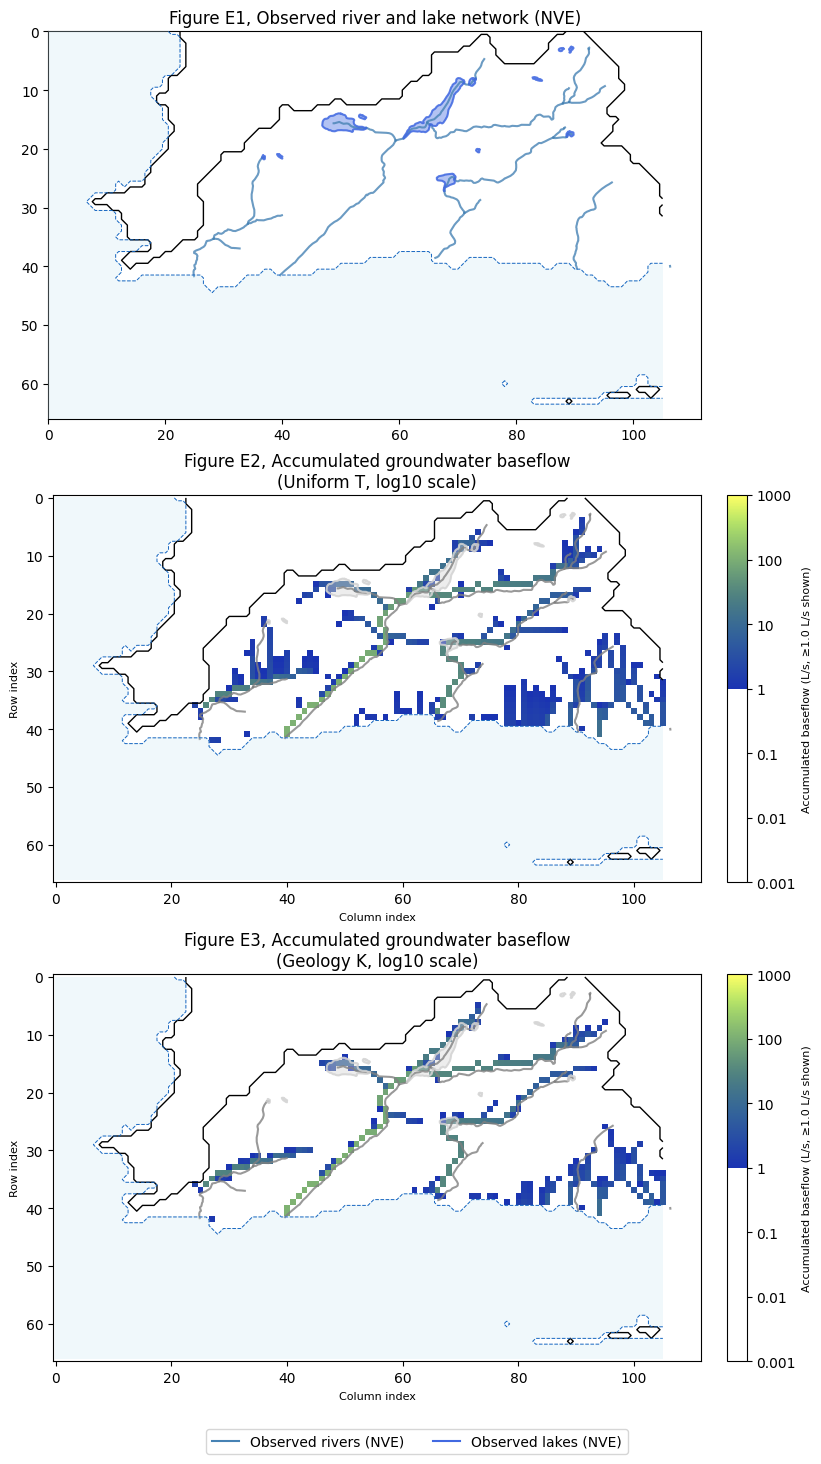

Baseflow routing figure saved to exercise5_baseflow_routing.png

Baseflow routing summary:
  Uniform T - total seepage: 319.99 L/s  | max accumulated: 112.41 L/s
  Geology K - total seepage: 288.61 L/s  | max accumulated: 115.97 L/s

Note: the maximum accumulated flux equals the total seepage only when there is a single outlet cell. Multiple outlets (coast, lake) will give lower maxima.


In [95]:
if RUN_BASEFLOW_ROUTING:
    # ── 2. Load observed river / lake network from Exercise 5A ──────────────────
    # The file rivers_lakes.geojson was written by exercise_5a_model_data.ipynb.
    # We convert the vector geometries to pixel (column, row) coordinates using
    # the model grid affine transform so they can be overlaid on imshow() plots.
    _rl_path = data_dir / 'rivers_lakes.geojson'
    _river_segments = []   # list of lists of (col, row)
    _lake_segments  = []   # list of lists of (col, row)

    if _rl_path.exists():
        with open(_rl_path) as _f:
            _rl_data = _json.load(_f)
        for _feat in _rl_data.get('features', []):
            _ftype = _feat['properties'].get('feature_type', 'river')
            _geom  = _feat['geometry']
            if _geom is None:
                continue
            _target = _river_segments if _ftype == 'river' else _lake_segments
            for _seg in _collect_line_segments(_geom, transform):
                _target.append(_seg)
        print(f'Loaded observed network: {len(_river_segments)} river segment(s), '
              f'{len(_lake_segments)} lake outline(s)  ← {_rl_path.name}')
    else:
        print(f'rivers_lakes.geojson not found at {_rl_path}, overlay skipped.')
        print('Run exercise_5a_model_data.ipynb first to generate this file.')


    # ── 3. Plot: accumulated baseflow maps with observed network overlay ──────────
    fig, axes = plt.subplots(3, 1, figsize=(8, 14), constrained_layout=True)

    _overlay_observed_network(axes[0])
    axes[0].set_title('Figure E1, Observed river and lake network (NVE)')
    _plot_baseflow_acc(acc_uniform_ls, active,
                       'Figure E2, Accumulated groundwater baseflow\n'
                       '(Uniform T, log10 scale)', axes[1],
                       cutoff_ls=baseflow_perennial_cutoff_ls)
    _plot_baseflow_acc(acc_geo_ls,     active,
                       'Figure E3, Accumulated groundwater baseflow\n'
                       '(Geology K, log10 scale)', axes[2],
                       cutoff_ls=baseflow_perennial_cutoff_ls)

    add_map_overlays(axes[0])  # add coastlines, grid ticks, etc. to the first plot
    add_map_overlays(axes[1])  # add coastlines, grid ticks, etc. to the second plot
    add_map_overlays(axes[2])  # add coastlines, grid ticks, etc. to the third plot

    axes[0].invert_yaxis()  # match the y-axis orientation of the imshow subplots below

    # Add a shared legend for the observed network overlay
    _handles = [
        _mlines.Line2D([], [], color='steelblue', linewidth=1.5, label='Observed rivers (NVE)'),
        _mlines.Line2D([], [], color='royalblue', linewidth=1.5, label='Observed lakes (NVE)'),
    ]
    fig.legend(handles=_handles, loc='lower center', ncol=2,
               frameon=True, bbox_to_anchor=(0.5, -0.04))

    #plt.suptitle(
    #    'Part E: Groundwater baseflow routing, D8 accumulation of model drain fluxes\n'
    #    '(baseflow only; does not include precipitation or surface runoff)', y=1.01
    #)
    plt.show()
    fig.savefig('exercise5_baseflow_routing.png', dpi=300, bbox_inches='tight')
    print(f'Baseflow routing figure saved to {"exercise5_baseflow_routing.png"}')


    # ── 4. Comparison: total seepage vs accumulated outlet flux ──────────────────
    # The maximum accumulated flux should be close to the total seepage
    # (all water eventually reaches an outlet cell).
    total_seepage_uniform_ls = seepage_uniform.sum() * 1000.0
    total_seepage_geo_ls     = seepage_geo.sum() * 1000.0
    max_acc_uniform_ls = acc_uniform_ls[active].max()
    max_acc_geo_ls     = acc_geo_ls[active].max()

    print()
    print('Baseflow routing summary:')
    print(f'  Uniform T - total seepage: {total_seepage_uniform_ls:.2f} L/s  '
          f'| max accumulated: {max_acc_uniform_ls:.2f} L/s')
    print(f'  Geology K - total seepage: {total_seepage_geo_ls:.2f} L/s  '
          f'| max accumulated: {max_acc_geo_ls:.2f} L/s')
    print()
    print('Note: the maximum accumulated flux equals the total seepage only when there is a'
          ' single outlet cell. Multiple outlets (coast, lake) will give lower maxima.')
